# Taco experiments

## Why Additional Experiments Are Needed

The previous training notebook produced a first Mask R-CNN baseline, but the validation results were not satisfactory. Both training stages showed low `bbox_map_50`, and full fine-tuning did not provide a meaningful improvement over head-only training.

This suggests that the problem is not only the number of trainable parameters or the length of training. The dataset itself may contain factors that make detection and classification difficult: many small objects, strong class imbalance, visually similar categories, noisy labels, and possible differences between bounding boxes and masks.

This notebook therefore focuses on targeted hypotheses about the data and the model behavior. Instead of simply training longer, each experiment checks one possible reason for low quality and measures whether changing the dataset setup or training configuration improves validation metrics.


## Experiment Plan

The notebook investigates several hypotheses:

- **Class granularity:** too many classes may hurt detection quality, so classless, top-5, and top-10 label setups are compared.
- **Noisy classes:** some classes may be visually ambiguous or mislabeled, causing class confusion.
- **Sampler effect:** the weighted sampler may help rare classes, but it may also distort the training distribution.
- **Bounding-box source:** original annotation boxes and mask-derived boxes may lead to different localization quality.
- **Object size:** small objects may be the main reason for low detection and classification performance.
- **Other class:** the broad `Other` class may be too heterogeneous and may compete with real classes.

The main metric remains `bbox_map_50`, because it matches the project scoring requirement. Additional metrics such as `match_rate`, `class_accuracy_on_matches`, and per-class diagnostics are used to explain why the main score changes.


## Install packages

In [1]:
!pip install torchmetrics pycocotools gdown tqdm tensorboard albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 14.6 MB/s eta 0:00:00a 0:00:01


## Import Packages

In [2]:
import os
import pandas as pd
import json
from tqdm import tqdm

import ast
from PIL import Image, ImageDraw
import os
import torch
import math

import numpy as np
from torchvision.io import read_image
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F
from torch.utils.data import Dataset, Subset, DataLoader, random_split, WeightedRandomSampler
from torch import nn
import random
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torch.utils.tensorboard import SummaryWriter
from matplotlib import colors, pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2

ROOT_PATH = "/home/ubuntu"
DEFAULT_RUNS_PATH = os.path.join(ROOT_PATH, "taco_trash")
COLAB_PATH = "/home/ubuntu"

from torchvision.ops import box_iou

from torchmetrics.detection import (
    MeanAveragePrecision,
    IntersectionOverUnion,
    GeneralizedIntersectionOverUnion,
    DistanceIntersectionOverUnion,
    CompleteIntersectionOverUnion,
)
from torchmetrics.segmentation import DiceScore, GeneralizedDiceScore, MeanIoU

%matplotlib inline

## Set Environment Paths

In [3]:
def is_google_colab() -> bool:
    """Return True when the notebook is executed inside Google Colab."""
    try:
        import google.colab
        return True
    except ImportError:
        return False


IN_COLAB = is_google_colab()

if IN_COLAB:
    ROOT_PATH = "/content"
    DATAFRAME_PATH = "/content/drive/MyDrive/taco_trash"
    DEFAULT_RUNS_PATH = "/content/drive/MyDrive/taco_trash"
else:
    ROOT_PATH = "/home/ubuntu"
    DATAFRAME_PATH = os.path.join(ROOT_PATH, "taco_trash")
    DEFAULT_RUNS_PATH = os.path.join(ROOT_PATH, "taco_trash")

TACO_CLASSIFICATION_PATH = os.path.join(ROOT_PATH, "taco")

In [4]:
if is_google_colab():
    from google.colab import drive
    drive.mount("/content/drive")
else:
    !curl https://rclone.org/install.sh | sudo bash

Mounted at /content/drive


In [5]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [6]:
torch.cuda.current_device()
torch.cuda.get_device_name(0)
device = torch.device("cuda")
device

AssertionError: Torch not compiled with CUDA enabled

## Download data

In [ ]:
!gdown 1CUxA2TcZFhVJWvNH4qwlOSGDPlxodRPF
!unzip taco.zip -d /home/ubuntu

Downloading...
From (original): https://drive.google.com/uc?id=1CUxA2TcZFhVJWvNH4qwlOSGDPlxodRPF
From (redirected): https://drive.google.com/uc?id=1CUxA2TcZFhVJWvNH4qwlOSGDPlxodRPF&confirm=t&uuid=d2a109eb-e6b1-4c54-bc4c-24a74b92c7bb
To: /home/ubuntu/taco.zip
100%|█████████████████████████████████████| 5.23G/5.23G [01:06<00:00, 79.0MB/s]
Archive:  taco.zip
   creating: /home/ubuntu/content/drive/MyDrive/taco_dataset/taco/
  inflating: /home/ubuntu/content/drive/MyDrive/taco_dataset/taco/annotations.json  
   creating: /home/ubuntu/content/drive/MyDrive/taco_dataset/taco/batch_14/
  inflating: /home/ubuntu/content/drive/MyDrive/taco_dataset/taco/batch_14/000011.jpg  
  inflating: /home/ubuntu/content/drive/MyDrive/taco_dataset/taco/batch_14/000007.jpg  
  inflating: /home/ubuntu/content/drive/MyDrive/taco_dataset/taco/batch_14/000004.jpg  
  inflating: /home/ubuntu/content/drive/MyDrive/taco_dataset/taco/batch_14/000000.jpg  
  inflating: /home/ubuntu/content/drive/MyDrive/taco_dataset/t

In [ ]:
!gdown 1lj6H8pIbHjgrgNRWHoc41Nr8bi0FZ7mt # annotations_processed.csv

In [ ]:
df = pd.read_csv(os.path.join(ROOT_PATH, "annotations_processed.csv"))

## Setup common functions

In [ ]:
def polygons_to_masks(segmentation, height, width):
    masks = []

    for seg in segmentation:
        # Create empty mask
        mask = Image.new("L", (width, height), 0)
        draw = ImageDraw.Draw(mask)

        # Create corrdinates tuples
        polygon = [(seg[i], seg[i+1]) for i in range(0, len(seg), 2)]

        # Fill this mask in empty mask image
        draw.polygon(polygon, outline=1, fill=1)

        #  PIL => numpy => torch
        mask = torch.from_numpy(np.array(mask, dtype=np.uint8))

        masks.append(mask)

    # Combine
    if len(masks) > 0:
        masks = torch.stack(masks)  # [N, H, W]
    else:
        masks = torch.zeros((0, height, width), dtype=torch.uint8)

    return masks

def boxes_from_masks(masks):
    boxes = []

    for mask in masks:
        ys, xs = torch.where(mask > 0)

        if len(xs) == 0 or len(ys) == 0:
            boxes.append([0.0, 0.0, 0.0, 0.0])
            continue

        x1 = xs.min().item()
        y1 = ys.min().item()
        x2 = xs.max().item() + 1
        y2 = ys.max().item() + 1

        boxes.append([float(x1), float(y1), float(x2), float(y2)])

    return torch.tensor(boxes, dtype=torch.float32)

def masks_to_boxes(masks):
    boxes = []

    for mask in masks:
        ys, xs = torch.where(mask > 0)

        if len(xs) == 0 or len(ys) == 0:
            boxes.append([0, 0, 0, 0])
            continue

        x1 = xs.min().item()
        y1 = ys.min().item()
        x2 = xs.max().item() + 1
        y2 = ys.max().item() + 1

        boxes.append([x1, y1, x2, y2])

    return torch.tensor(boxes, dtype=torch.float32)

class TacoDatasetOriginalBoxes(Dataset):
    def __init__(
        self,
        df,
        label_map,
        label_col="category_id",
        transform=None,
        return_masks=True,
        use_original_boxes=True,
    ):
        self.image_groups = list(df.groupby("image_id"))
        self.label_map = label_map
        self.label_col = label_col
        self.transform = transform
        self.return_masks = return_masks
        self.use_original_boxes = use_original_boxes

    def __getitem__(self, idx):
        image_id, group = self.image_groups[idx]
        file_path = group.iloc[0]["file_path"]

        img = read_image(file_path).float() / 255.0
        _, H, W = img.shape

        boxes = []
        labels = []
        masks = []

        for _, row in group.iterrows():
            label = self.label_map[row[self.label_col]]
            labels.append(label)

            bbox = ast.literal_eval(row["bbox"]) if isinstance(row["bbox"], str) else row["bbox"]
            x, y, w, h = bbox
            boxes.append([x, y, x + w, y + h])

            if self.return_masks or self.transform is not None:
                segmentation = ast.literal_eval(row["segmentation"]) if isinstance(row["segmentation"],
                str) else row["segmentation"]
                mask = polygons_to_masks(segmentation, H, W)
                mask = mask.sum(dim=0).clamp(max=1).to(torch.uint8)
                masks.append(mask)

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        boxes[:, [0, 2]] = boxes[:, [0, 2]].clamp(0, W)
        boxes[:, [1, 3]] = boxes[:, [1, 3]].clamp(0, H)

        if len(masks) > 0:
            masks = torch.stack(masks)
        else:
            masks = torch.zeros((len(labels), H, W), dtype=torch.uint8)

        if self.transform is not None:
            image_np = (img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            masks_np = [m.numpy() for m in masks]

            transformed = self.transform(
                image=image_np,
                masks=masks_np,
            )

            image_np = transformed["image"]
            masks_np = transformed["masks"]

            img = torch.from_numpy(image_np).permute(2, 0, 1).float() / 255.0

            masks = torch.stack([
                torch.from_numpy(m.astype(np.uint8))
                for m in masks_np
            ])

            boxes = masks_to_boxes(masks)

        keep = (
            (boxes[:, 2] > boxes[:, 0])
            & (boxes[:, 3] > boxes[:, 1])
        )

        if self.return_masks or self.transform is not None:
            keep = keep & (masks.flatten(1).sum(dim=1) > 0)

        boxes = boxes[keep]
        labels = labels[keep]
        masks = masks[keep]

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([image_id]),
            "area": (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]),
            "iscrowd": torch.zeros((len(boxes),), dtype=torch.int64),
        }

        if self.return_masks:
            target["masks"] = masks

        return img, target

    def __len__(self):
        return len(self.image_groups)

In [ ]:
from collections import Counter

def collate_fn(batch):
    return tuple(zip(*batch))

def get_loaders(
    df,
    label_map,
    label_col="supercategory_reduced",
    train_transform=None,
    return_masks=True,
    use_original_boxes=True,
    train_batch_size=2,
    val_batch_size=4,
    pin_memory=False,
    num_workers=2
):
    base_dataset = TacoDatasetOriginalBoxes(
      df=df,
      label_map=label_map,
      label_col=label_col,
      transform=None,
      return_masks=return_masks,
      use_original_boxes=use_original_boxes
    )

    train_size = int(0.8 * len(base_dataset))
    val_size = len(base_dataset) - train_size

    train_indices, val_indices = torch.utils.data.random_split(
        range(len(base_dataset)),
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42),
    )

    train_dataset_full = TacoDatasetOriginalBoxes(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=train_transform,
        return_masks=return_masks,
        use_original_boxes=use_original_boxes
    )

    val_dataset_full = TacoDatasetOriginalBoxes(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=None,
        return_masks=return_masks,
        use_original_boxes=use_original_boxes
    )
    train_dataset = Subset(train_dataset_full, train_indices.indices)
    val_dataset = Subset(val_dataset_full, val_indices.indices)
    class_counts = Counter()

    for dataset_idx in train_dataset.indices:
        image_id, group = base_dataset.image_groups[dataset_idx]

        labels = [
            label_map[cat_id]
            for cat_id in group[label_col].tolist()
        ]

        class_counts.update(labels)

    class_weights = {
        cls: 1.0 / np.sqrt(count)
        for cls, count in class_counts.items()
    }
    sample_weights = []

    for dataset_idx in train_dataset.indices:
        image_id, group = base_dataset.image_groups[dataset_idx]

        labels = [
            label_map[cat_id]
            for cat_id in group[label_col].tolist()
        ]

        weight = max(class_weights[label] for label in labels)
        sample_weights.append(weight)

    sample_weights = torch.DoubleTensor(sample_weights)

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=train_batch_size,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=False,
        sampler=sampler,
        collate_fn=collate_fn
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=val_batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=False,
        collate_fn=collate_fn
    )
    return train_loader, val_loader


In [ ]:
def get_model(num_classes, train_mode="heads"):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(
        weights="DEFAULT",
        min_size=1024,
        max_size=1536,
    )

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask,
        256,
        num_classes,
    )

    for p in model.parameters():
        p.requires_grad = False

    if train_mode == "predictors":
        for p in model.roi_heads.box_predictor.parameters():
            p.requires_grad = True
        for p in model.roi_heads.mask_predictor.parameters():
            p.requires_grad = True

    elif train_mode == "heads":
        for p in model.rpn.parameters():
            p.requires_grad = True
        for p in model.roi_heads.parameters():
            p.requires_grad = True

    elif train_mode == "all":
        for p in model.parameters():
            p.requires_grad = True

    model.to(device)
    return model

def set_train_mode(model, train_mode):
    for p in model.parameters():
        p.requires_grad = False

    if train_mode == "predictors":
        for p in model.roi_heads.box_predictor.parameters():
            p.requires_grad = True
        for p in model.roi_heads.mask_predictor.parameters():
            p.requires_grad = True

    elif train_mode == "heads":
        for p in model.rpn.parameters():
            p.requires_grad = True
        for p in model.roi_heads.parameters():
            p.requires_grad = True

    elif train_mode == "all":
        for p in model.parameters():
            p.requires_grad = True

    else:
        raise ValueError(f"Unknown train_mode: {train_mode}")

def get_model_v2(num_classes, train_mode="heads"):
      model = torchvision.models.detection.maskrcnn_resnet50_fpn_v2(
          weights="DEFAULT",
          min_size=1024,
          max_size=1536,
      )

      in_features = model.roi_heads.box_predictor.cls_score.in_features
      model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

      in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
      model.roi_heads.mask_predictor = MaskRCNNPredictor(
          in_features_mask,
          256,
          num_classes,
      )

      for p in model.parameters():
          p.requires_grad = False

      if train_mode == "predictors":
          for p in model.roi_heads.box_predictor.parameters():
              p.requires_grad = True
          for p in model.roi_heads.mask_predictor.parameters():
              p.requires_grad = True

      elif train_mode == "heads":
          for p in model.rpn.parameters():
              p.requires_grad = True
          for p in model.roi_heads.parameters():
              p.requires_grad = True

      elif train_mode == "all":
          for p in model.parameters():
              p.requires_grad = True

      else:
          raise ValueError(f"Unknown train_mode: {train_mode}")

      model.to(device)
      return model

In [ ]:
def fit_one_epoch(model, train_dataloader, optimizer, device, epoch, scaler=None, max_grad_norm=5.0):
    model.to(device)
    model.train()

    total_loss_sum = 0.0
    num_batches = 0

    loss_sums = {
        "loss_classifier": 0.0,
        "loss_box_reg": 0.0,
        "loss_mask": 0.0,
        "loss_objectness": 0.0,
        "loss_rpn_box_reg": 0.0,
    }

    loader = tqdm(
        train_dataloader,
        total=len(train_dataloader),
        position=0,
        leave=True,
        dynamic_ncols=True,
        desc=f"Epoch {epoch+1}. Train"
    )
    for batch_idx, (images, targets) in enumerate(loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=scaler is not None):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())


        if not torch.isfinite(losses):
          print(f"non-finite loss at batch {batch_idx}")
          break

        if losses.item() > 1e6:
            print(f"exploding loss at batch {batch_idx}")
            print("targets summary:")
            for i, t in enumerate(targets):
                print(
                    i,
                    t["boxes"].shape,
                    t["labels"].tolist(),
                    t["masks"].shape,
                )
            break

        if scaler is not None:
            scaler.scale(losses).backward()
            scaler.unscale_(optimizer)

            grad_norm = torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad],
                max_norm=max_grad_norm,
            )

            scaler.step(optimizer)
            scaler.update()
        else:
            losses.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad],
                max_norm=max_grad_norm,
            )

            optimizer.step()

        total_loss_sum += losses.item()
        num_batches += 1

        for key in loss_sums:
            loss_sums[key] += loss_dict[key].item()

    if num_batches == 0:
        raise ValueError(
            f"fit_one_epoch: no successful batches were processed in epoch {epoch}"
        )

    metrics = {
        "epoch": epoch,
        "total_loss": total_loss_sum / num_batches,
        "grad_norm": float(grad_norm.detach().cpu()) if isinstance(grad_norm, torch.Tensor) else
          float(grad_norm),
    }

    for key in loss_sums:
        metrics[key] = loss_sums[key] / num_batches

    return metrics

In [ ]:
def _to_float(x):
    if isinstance(x, torch.Tensor):
        if x.numel() == 1:
            value = float(x.detach().cpu().item())
            if math.isnan(value) or math.isinf(value):
                return None
            return value
        return None

    if isinstance(x, (int, float)):
        value = float(x)
        if math.isnan(value) or math.isinf(value):
            return None
        return value

    return None

def _to_list(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu()
        if x.ndim == 0:
            return [x.item()]
        return x.tolist()

    if isinstance(x, (int, float)):
        return [float(x)]

    if isinstance(x, list):
        return x

    return []

def iou_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5):
    # Lets compute metrics for some threshold
    # first convert mask values to probabilities, then
    # apply thresholding

    prob_mask = logits.sigmoid()
    pred_mask = (prob_mask > threshold).float()

    tp = torch.sum(pred_mask*labels)
    fp = torch.sum(pred_mask) - tp
    fn = torch.sum(labels) - tp

    eps = 1e-8 # to avoid 0/0
    iou = (tp + eps) / (tp + fp + fn + eps)

    return iou

def prepare_detection_batch(preds, targets, mask_threshold=0.5):
    bbox_preds = []
    bbox_targets = []

    segm_preds = []
    segm_targets = []

    for pred, target in zip(preds, targets):
        pred_boxes = pred["boxes"].detach().cpu()
        pred_scores = pred["scores"].detach().cpu()
        pred_labels = pred["labels"].detach().cpu().to(torch.int64)

        gt_boxes = target["boxes"].detach().cpu()
        gt_labels = target["labels"].detach().cpu().to(torch.int64)

        bbox_preds.append({
            "boxes": pred_boxes,
            "scores": pred_scores,
            "labels": pred_labels,
        })

        bbox_targets.append({
            "boxes": gt_boxes,
            "labels": gt_labels,
        })

        segm_pred = {
            "boxes": pred_boxes,
            "scores": pred_scores,
            "labels": pred_labels,
        }
        if "masks" in pred:
            # pred masks come as [N, 1, H, W] floats
            segm_pred["masks"] = (pred["masks"].detach().cpu().squeeze(1) >= mask_threshold)

        segm_target = {
            "boxes": gt_boxes,
            "labels": gt_labels,
        }
        if "masks" in target:
            # gt masks are [N, H, W]
            segm_target["masks"] = target["masks"].detach().cpu().bool()

        segm_preds.append(segm_pred)
        segm_targets.append(segm_target)

    return bbox_preds, bbox_targets, segm_preds, segm_targets

def match_instance_masks(pred, target, box_iou_threshold=0.5, mask_threshold=0.5):
    """
    Returns matched predicted masks and gt masks as [M, H, W] long tensors,
    where M is number of matched instances.
    """
    if len(pred["boxes"]) == 0 or len(target["boxes"]) == 0:
        return None, None

    pred_boxes = pred["boxes"].detach().cpu()
    pred_labels = pred["labels"].detach().cpu()
    pred_masks = (pred["masks"].detach().cpu().squeeze(1) >= mask_threshold)  # [Np, H, W]

    gt_boxes = target["boxes"].detach().cpu()
    gt_labels = target["labels"].detach().cpu()
    gt_masks = target["masks"].detach().cpu().bool()  # [Ng, H, W]

    ious = box_iou(pred_boxes, gt_boxes)  # [Np, Ng]
    same_label = pred_labels[:, None] == gt_labels[None, :]
    ious = ious * same_label.float()

    matched_pred_masks = []
    matched_gt_masks = []

    used_pred = set()
    used_gt = set()

    while True:
        max_iou = ious.max().item()
        if max_iou < box_iou_threshold:
            break

        flat_idx = ious.argmax().item()
        num_gt = ious.shape[1]
        pred_idx = flat_idx // num_gt
        gt_idx = flat_idx % num_gt

        if pred_idx in used_pred or gt_idx in used_gt:
            ious[pred_idx, gt_idx] = -1
            continue

        matched_pred_masks.append(pred_masks[pred_idx].long())
        matched_gt_masks.append(gt_masks[gt_idx].long())

        used_pred.add(pred_idx)
        used_gt.add(gt_idx)

        ious[pred_idx, :] = -1
        ious[:, gt_idx] = -1

    if len(matched_pred_masks) == 0:
        return None, None

    return torch.stack(matched_pred_masks), torch.stack(matched_gt_masks)

In [ ]:
def prepare_eval_metrics_for_tensorboard(eval_results, id_to_name=None):
    flat = {}

    # bbox mAP dict
    bbox_map = eval_results["bbox_map"]
    flat["eval/bbox_map"] = _to_float(bbox_map.get("map"))
    flat["eval/bbox_map_50"] = _to_float(bbox_map.get("map_50"))
    flat["eval/bbox_map_75"] = _to_float(bbox_map.get("map_75"))
    flat["eval/bbox_mar_100"] = _to_float(bbox_map.get("mar_100"))

    # segm mAP dict
    if "segm_map" in eval_results:
        segm_map = eval_results["segm_map"]
        flat["eval/segm_map"] = _to_float(segm_map.get("map"))
        flat["eval/segm_map_50"] = _to_float(segm_map.get("map_50"))
        flat["eval/segm_map_75"] = _to_float(segm_map.get("map_75"))
        flat["eval/segm_mar_100"] = _to_float(segm_map.get("mar_100"))

    # box overlap metrics
    if "bbox_iou" in eval_results:
        flat["eval/bbox_iou"] = _to_float(eval_results["bbox_iou"])
        flat["eval/bbox_giou"] = _to_float(eval_results["bbox_giou"])
        flat["eval/bbox_diou"] = _to_float(eval_results["bbox_diou"])
        flat["eval/bbox_ciou"] = _to_float(eval_results["bbox_ciou"])

    # mask metrics
    if "dice" in eval_results:
        flat["eval/dice"] = _to_float(eval_results["dice"])
        flat["eval/generalized_dice"] = _to_float(eval_results["generalized_dice"])
        flat["eval/mask_miou"] = _to_float(eval_results["mask_miou"])

    if "debug" in eval_results:
        for key, value in eval_results["debug"].items():
            flat[f"eval/{key}"] = _to_float(value)

    # Per-class bbox AP
    if "classes" in bbox_map and "map_per_class" in bbox_map:
        classes = _to_list(bbox_map["classes"])
        values = _to_list(bbox_map["map_per_class"])

        for cls, value in zip(classes, values):
            cls = int(cls)
            cls_name = id_to_name.get(cls, str(cls)) if id_to_name else str(cls)
            flat[f"eval_per_class/bbox_map/{cls_name}"] = _to_float(value)

    # Per-class bbox recall
    if "classes" in bbox_map and "mar_100_per_class" in bbox_map:
        classes = _to_list(bbox_map["classes"])
        values = _to_list(bbox_map["mar_100_per_class"])

        for cls, value in zip(classes, values):
            cls = int(cls)
            cls_name = id_to_name.get(cls, str(cls)) if id_to_name else str(cls)
            flat[f"eval_per_class/bbox_mar_100/{cls_name}"] = _to_float(value)

    # Per-class mask AP
    if "segm_map" in eval_results:
        segm_map = eval_results["segm_map"]
        if "classes" in segm_map and "map_per_class" in segm_map:
            classes = _to_list(segm_map["classes"])
            values = _to_list(segm_map["map_per_class"])

            for cls, value in zip(classes, values):
                cls = int(cls)
                cls_name = id_to_name.get(cls, str(cls)) if id_to_name else str(cls)
                flat[f"eval_per_class/segm_map/{cls_name}"] = _to_float(value)

    # remove unsupported / None values
    flat = {k: v for k, v in flat.items() if v is not None}
    return flat

def prepare_train_metrics_for_tensorboard(train_metrics):
    return {
        "train/total_loss": float(train_metrics["total_loss"]),
        "train/loss_classifier": float(train_metrics["loss_classifier"]),
        "train/loss_box_reg": float(train_metrics["loss_box_reg"]),
        "train/loss_mask": float(train_metrics["loss_mask"]),
        "train/loss_objectness": float(train_metrics["loss_objectness"]),
        "train/loss_rpn_box_reg": float(train_metrics["loss_rpn_box_reg"]),
    }

In [ ]:
from torchvision.ops import box_iou

def detection_debug_stats(outputs, targets, score_threshold=0.05, iou_threshold=0.5):
    stats = {
        "gt_instances": 0,
        "pred_instances": 0,
        "matched_instances": 0,
        "class_correct_matches": 0,
        "images_with_no_predictions": 0,
        "images_with_no_matches": 0,
        "top1_scores": [],
        "matched_scores": [],
        "unmatched_scores": [],
    }

    for out, target in zip(outputs, targets):
        scores = out["scores"].detach().cpu()
        keep = scores >= score_threshold

        pred_boxes = out["boxes"].detach().cpu()[keep]
        pred_labels = out["labels"].detach().cpu()[keep]
        pred_scores = scores[keep]

        gt_boxes = target["boxes"].detach().cpu()
        gt_labels = target["labels"].detach().cpu()

        stats["gt_instances"] += len(gt_boxes)
        stats["pred_instances"] += len(pred_boxes)

        if len(scores) > 0:
            stats["top1_scores"].append(float(scores[0]))

        if len(pred_boxes) == 0:
            stats["images_with_no_predictions"] += 1
            stats["images_with_no_matches"] += 1
            continue

        if len(gt_boxes) == 0:
            stats["unmatched_scores"].extend(pred_scores.tolist())
            continue

        ious = box_iou(pred_boxes, gt_boxes)

        matched_pred = set()
        matched_gt = set()

        while ious.numel() > 0:
            max_iou = ious.max().item()
            if max_iou < iou_threshold:
                break

            flat_idx = ious.argmax().item()
            pred_idx = flat_idx // ious.shape[1]
            gt_idx = flat_idx % ious.shape[1]

            if pred_idx in matched_pred or gt_idx in matched_gt:
                ious[pred_idx, gt_idx] = -1
                continue

            matched_pred.add(pred_idx)
            matched_gt.add(gt_idx)

            stats["matched_instances"] += 1
            stats["matched_scores"].append(float(pred_scores[pred_idx]))

            if int(pred_labels[pred_idx]) == int(gt_labels[gt_idx]):
                stats["class_correct_matches"] += 1

            ious[pred_idx, :] = -1
            ious[:, gt_idx] = -1

        if len(matched_gt) == 0:
            stats["images_with_no_matches"] += 1

        for pred_idx, score in enumerate(pred_scores):
            if pred_idx not in matched_pred:
                stats["unmatched_scores"].append(float(score))

    return stats

In [ ]:
@torch.no_grad()
def eval_one_epoch(
    model,
    val_dataloader,
    device,
    epoch,
    score_threshold=0.3,
    mask_threshold=0.3,
    detections_per_img=5,
    match_iou_threshold=0.5,
    fast=False
):
    model.eval()
    running_debug = {
        "gt_instances": 0,
        "pred_instances": 0,
        "matched_instances": 0,
        "class_correct_matches": 0,
        "images_with_no_predictions": 0,
        "images_with_no_matches": 0,
        "top1_scores": [],
        "matched_scores": [],
        "unmatched_scores": [],
    }
    model.roi_heads.score_thresh = score_threshold
    model.roi_heads.detections_per_img = detections_per_img

    bbox_map = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")
    if not fast:
        segm_map = MeanAveragePrecision(box_format="xyxy", iou_type="segm")

        bbox_iou_metric = IntersectionOverUnion()
        bbox_giou_metric = GeneralizedIntersectionOverUnion()
        bbox_diou_metric = DistanceIntersectionOverUnion()
        bbox_ciou_metric = CompleteIntersectionOverUnion()

        dice_metric = DiceScore(
            num_classes=2,
            average="micro",
            include_background=False,
            input_format="index",
        )
        gdice_metric = GeneralizedDiceScore(
            num_classes=2,
            include_background=False,
            input_format="index",
        )
        miou_metric = MeanIoU(
            num_classes=2,
            include_background=False,
            input_format="index",
        )

    matched_mask_count = 0

    loader = tqdm(
        val_dataloader,
        total=len(val_dataloader),
        position=0,
        leave=True,
        dynamic_ncols=True,
        desc=f"Epoch {epoch+1}. Eval"
)
    for batch_idx, (images, targets) in enumerate(loader):

        images = [img.to(device) for img in images]

        with torch.amp.autocast("cuda"):
            outputs = model(images)

        debug_stats = detection_debug_stats(
            outputs=outputs,
            targets=targets,
            score_threshold=0.05,
            iou_threshold=0.5,
        )

        for key in [
            "gt_instances",
            "pred_instances",
            "matched_instances",
            "class_correct_matches",
            "images_with_no_predictions",
            "images_with_no_matches",
        ]:
            running_debug[key] += debug_stats[key]

        for key in [
            "top1_scores",
            "matched_scores",
            "unmatched_scores",
        ]:
            running_debug[key].extend(debug_stats[key])

        bbox_preds, bbox_targets, segm_preds, segm_targets = prepare_detection_batch(
            outputs,
            targets,
            mask_threshold=mask_threshold,
        )

        bbox_map.update(bbox_preds, bbox_targets)
        # segm_map.update(segm_preds, segm_targets)
        if not fast:
            if any("masks" in p for p in segm_preds):
                segm_map.update(segm_preds, segm_targets)

            bbox_iou_metric.update(bbox_preds, bbox_targets)
            bbox_giou_metric.update(bbox_preds, bbox_targets)
            bbox_diou_metric.update(bbox_preds, bbox_targets)
            bbox_ciou_metric.update(bbox_preds, bbox_targets)

            for target, out in zip(targets, outputs):
                if "masks" not in out or "masks" not in target:
                    continue

                pred_masks, gt_masks = match_instance_masks(
                    out,
                    target,
                    box_iou_threshold=match_iou_threshold,
                    mask_threshold=mask_threshold,
                )

                if pred_masks is None:
                    continue

                dice_metric.update(pred_masks, gt_masks)
                gdice_metric.update(pred_masks, gt_masks)
                miou_metric.update(pred_masks, gt_masks)

                matched_mask_count += pred_masks.shape[0]

        del images, outputs

    if matched_mask_count > 0:
        dice = dice_metric.compute()
        generalized_dice = gdice_metric.compute()
        mask_miou = miou_metric.compute()
    else:
        dice = torch.tensor(float("nan"))
        generalized_dice = torch.tensor(float("nan"))
        mask_miou = torch.tensor(float("nan"))

    gt = max(running_debug["gt_instances"], 1)
    matched = max(running_debug["matched_instances"], 1)

    debug_results = {
        "gt_instances": running_debug["gt_instances"],
        "pred_instances": running_debug["pred_instances"],
        "matched_instances": running_debug["matched_instances"],
        "match_rate": running_debug["matched_instances"] / gt,
        "class_accuracy_on_matches": running_debug["class_correct_matches"] / matched,
        "images_with_no_predictions": running_debug["images_with_no_predictions"],
        "images_with_no_matches": running_debug["images_with_no_matches"],
        "mean_top1_score": float(np.mean(running_debug["top1_scores"])) if running_debug["top1_scores"] else
        0.0,
        "mean_matched_score": float(np.mean(running_debug["matched_scores"])) if
        running_debug["matched_scores"] else 0.0,
        "mean_unmatched_score": float(np.mean(running_debug["unmatched_scores"])) if
        running_debug["unmatched_scores"] else 0.0,
    }

    results = {
        "epoch": epoch,
        "bbox_map": bbox_map.compute(),
        "debug": debug_results,
    }

    if not fast:
        results.update({
            "segm_map":        segm_map.compute(),
            "bbox_iou":        bbox_iou_metric.compute(),
            "bbox_giou":       bbox_giou_metric.compute(),
            "bbox_diou":       bbox_diou_metric.compute(),
            "bbox_ciou":       bbox_ciou_metric.compute(),
            "dice":            dice if matched_mask_count > 0 else torch.tensor(float("nan")),
            "generalized_dice": generalized_dice if matched_mask_count > 0 else torch.tensor(float("nan")),
            "mask_miou":       mask_miou if matched_mask_count > 0 else torch.tensor(float("nan")),
        })

    torch.cuda.empty_cache()
    return results

@torch.no_grad()
def eval_one_epoch_bbox_only(
    model,
    val_dataloader,
    device,
    epoch,
    score_threshold=0.05,
    detections_per_img=20,
    match_iou_threshold=0.5,
):
    model.eval()

    previous_score_thresh = model.roi_heads.score_thresh
    previous_detections_per_img = model.roi_heads.detections_per_img

    model.roi_heads.score_thresh = score_threshold
    model.roi_heads.detections_per_img = detections_per_img

    bbox_map = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")

    running_debug = {
        "gt_instancess": 0,
        "pred_instances": 0,
        "matched_instances": 0,
        "class_correct_matches": 0,
        "images_with_no_predictions": 0,
        "images_with_no_matches": 0,
        "top1_scores": [],
        "matched_scores": [],
        "unmatched_scores": [],
    }

    loader = tqdm(
        val_dataloader,
        total=len(val_dataloader),
        position=0,
        leave=True,
        dynamic_ncols=True,
        desc=f"Epoch {epoch + 1}. BBox Eval",
    )

    try:
        for batch_idx, (images, targets) in enumerate(loader):
            images = [img.to(device) for img in images]

            with torch.amp.autocast("cuda", enabled=device.type == "cuda"):
                outputs = model(images)

            targets_for_metrics = [
                {
                    "boxes": t["boxes"].detach().cpu(),
                    "labels": t["labels"].detach().cpu().to(torch.int64),
                }
                for t in targets
            ]

            preds_for_metrics = [
                {
                    "boxes": out["boxes"].detach().cpu(),
                    "scores": out["scores"].detach().cpu(),
                    "labels": out["labels"].detach().cpu().to(torch.int64),
                }
                for out in outputs
            ]

            debug_stats = detection_debug_stats(
                outputs=preds_for_metrics,
                targets=targets_for_metrics,
                score_threshold=score_threshold,
                iou_threshold=match_iou_threshold,
            )

            for key in [
                "gt_instances",
                "pred_instances",
                "matched_instances",
                "class_correct_matches",
                "images_with_no_predictions",
                "images_with_no_matches",
            ]:
                running_debug[key] += debug_stats[key]

            for key in [
                "top1_scores",
                "matched_scores",
                "unmatched_scores",
            ]:
                running_debug[key].extend(debug_stats[key])

            bbox_map.update(preds_for_metrics, targets_for_metrics)

            del images, outputs, preds_for_metrics

    finally:
        model.roi_heads.score_thresh = previous_score_thresh
        model.roi_heads.detections_per_img = previous_detections_per_img

    gt = max(running_debug["gt_instances"], 1)
    matched = max(running_debug["matched_instances"], 1)

    debug_results = {
        "gt_instances": running_debug["gt_instances"],
        "pred_instances": running_debug["pred_instances"],
        "matched_instances": running_debug["matched_instances"],
        "match_rate": running_debug["matched_instances"] / gt,
        "class_accuracy_on_matches": running_debug["class_correct_matches"] / matched,
        "images_with_no_predictions": running_debug["images_with_no_predictions"],
        "images_with_no_matches": running_debug["images_with_no_matches"],
        "mean_top1_score": (
            float(np.mean(running_debug["top1_scores"]))
            if running_debug["top1_scores"]
            else 0.0
        ),
        "mean_matched_score": (
            float(np.mean(running_debug["matched_scores"]))
            if running_debug["matched_scores"]
            else 0.0
        ),
        "mean_unmatched_score": (
            float(np.mean(running_debug["unmatched_scores"]))
            if running_debug["unmatched_scores"]
            else 0.0
        ),
    }

    return {
        "epoch": epoch,
        "bbox_map": bbox_map.compute(),
        "debug": debug_results,
    }

In [ ]:
def save_checkpoint(path, model, optimizer, scheduler, scaler, epoch, score, metrics):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "score": score,
        "metrics": metrics,
    }

    if scheduler is not None:
        checkpoint["scheduler_state_dict"] = scheduler.state_dict()

    if scaler is not None:
        checkpoint["scaler_state_dict"] = scaler.state_dict()

    torch.save(checkpoint, path)

def load_checkpoint(path, model, optimizer=None, scheduler=None, scaler=None, device="cuda"):
    checkpoint = torch.load(path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)

    if optimizer is not None and "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if scheduler is not None and "scheduler_state_dict" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    if scaler is not None and "scaler_state_dict" in checkpoint:
        scaler.load_state_dict(checkpoint["scaler_state_dict"])

    return checkpoint

def step_scheduler_default(scheduler, train_metrics, val_metrics):
    if scheduler is None:
        return

    if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        scheduler.step(train_metrics["train/total_loss"])
    else:
        scheduler.step()

def step_on_train_loss(scheduler, train_metrics, val_metrics):
    if scheduler is None:
        return
    scheduler.step(train_metrics["train/total_loss"])

def step_on_val_segm_map_50(scheduler, train_metrics, val_metrics):
    if scheduler is None:
        return

    if val_metrics is None:
        return

    value = val_metrics.get("eval/segm_map_50")
    if value is None:
        return

    scheduler.step(value)

def step_on_val_bbox_map_50(scheduler, train_metrics, val_metrics):
    if scheduler is None or val_metrics is None:
        return

    value = val_metrics.get("eval/bbox_map_50")
    if value is None or not math.isfinite(value):
        return

    scheduler.step(value)

def score_by_train_loss(train_metrics, val_metrics):
      return -train_metrics["train/total_loss"], "-train/total_loss"


def score_by_eval_bbox_map_50(train_metrics, val_metrics):
    if val_metrics is None:
        return None, None

    value = val_metrics.get("eval/bbox_map_50")
    if value is None or not math.isfinite(value):
        return None, None

    return value, "eval/bbox_map_50"


def score_by_eval_segm_map_50(train_metrics, val_metrics):
    if val_metrics is None:
        return None, None

    value = val_metrics.get("eval/segm_map_50")
    if value is None or not math.isfinite(value):
        return None, None

    return value, "eval/segm_map_50"

def train_model(
      model,
      train_loader,
      val_loader,
      optimizer,
      scheduler,
      scaler,
      writer,
      num_epoch,
      run_prefix,
      device,
      checkpoint_dir="checkpoints",
      eval_every=1,
      metrics_csv_paths=None,
      scheduler_step_fn=None,
      checkpoint_score_fn=None,
      id_to_name=None,
      start_epoch=0,
      fast=False
  ):
    os.makedirs(checkpoint_dir, exist_ok=True)

    run_checkpoint_dir = os.path.join(checkpoint_dir, run_prefix)
    os.makedirs(run_checkpoint_dir, exist_ok=True)

    if scheduler_step_fn is None:
        scheduler_step_fn = step_scheduler_default

    if checkpoint_score_fn is None:
        checkpoint_score_fn = score_by_eval_segm_map_50

    metrics = {"train": [], "eval": []}
    best_score = -float("inf")
    best_epoch = None

    train_rows = []
    eval_rows = []

    if metrics_csv_paths is None:
        train_metrics_path = os.path.join(checkpoint_dir, f"{run_prefix}_train.csv")
        eval_metrics_path = os.path.join(checkpoint_dir, f"{run_prefix}_eval.csv")
    else:
        train_metrics_path = metrics_csv_paths["train"]
        eval_metrics_path = metrics_csv_paths["eval"]

    loader = tqdm(
        range(start_epoch, num_epoch),
        total=num_epoch - start_epoch,
        position=0,
        dynamic_ncols=True,
    )

    for epoch in loader:
        loader.set_description(f"Train model. Epoch {epoch + 1}")
        metrics_train = fit_one_epoch(
            model=model,
            optimizer=optimizer,
            train_dataloader=train_loader,
            device=device,
            epoch=epoch,
            scaler=scaler,
        )

        train_tb = prepare_train_metrics_for_tensorboard(metrics_train)

        train_dict_metrics = {"epoch": epoch}
        for name, value in train_tb.items():
            writer.add_scalar(name, value, epoch)
            train_dict_metrics[name] = value

        metrics["train"].append(train_dict_metrics)

        train_rows.append(dict(train_dict_metrics))
        pd.DataFrame(train_rows).to_csv(train_metrics_path, index=False)

        should_eval = (
            val_loader is not None
            and eval_every is not None
            and eval_every > 0
            and ((epoch + 1) % eval_every == 0)
        )

        val_dict_metrics = None

        if should_eval:
            metrics_val = eval_one_epoch(
                model=model,
                val_dataloader=val_loader,
                device=device,
                epoch=epoch,
                score_threshold=0.05,
                mask_threshold=0.5,
                detections_per_img=20,
                fast=fast
            )

            eval_tb = prepare_eval_metrics_for_tensorboard(
                metrics_val,
                id_to_name=id_to_name,
            )

            val_dict_metrics = {"epoch": epoch}
            for name, value in eval_tb.items():
                writer.add_scalar(name, value, epoch)
                val_dict_metrics[name] = value

            metrics["eval"].append(val_dict_metrics)

        checkpoint_score, checkpoint_metric = checkpoint_score_fn(
            train_dict_metrics,
            val_dict_metrics,
        )

        if checkpoint_score is None:
            checkpoint_score, checkpoint_metric = score_by_train_loss(
                train_dict_metrics,
                val_dict_metrics,
            )

        writer.add_scalar(f"{run_prefix}/checkpoint_score", checkpoint_score, epoch)
        writer.add_scalar(f"{run_prefix}/lr", optimizer.param_groups[0]["lr"], epoch)

        checkpoint_metrics = {
            "train": train_dict_metrics,
            "eval": val_dict_metrics,
            "checkpoint_metric": checkpoint_metric,
        }

        last_path = os.path.join(checkpoint_dir, f"{run_prefix}_last_model.pt")
        save_checkpoint(
            path=last_path,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            epoch=epoch,
            score=checkpoint_score,
            metrics=checkpoint_metrics,
        )

        if checkpoint_score > best_score:
            best_score = checkpoint_score
            best_epoch = epoch

            best_path = os.path.join(checkpoint_dir, f"{run_prefix}_best_model.pt")
            save_checkpoint(
                path=best_path,
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                scaler=scaler,
                epoch=epoch,
                score=best_score,
                metrics={
                    **checkpoint_metrics,
                    "best_epoch": best_epoch,
                    "best_score": best_score,
                },
            )

        if val_dict_metrics is not None:
            eval_row = {
                "epoch": epoch,
                "run_prefix": run_prefix,
                "checkpoint_score": checkpoint_score,
                "checkpoint_metric": checkpoint_metric,
                "best_score": best_score,
                "best_epoch": best_epoch,
                "lr": optimizer.param_groups[0]["lr"],
            }
            eval_row.update({k: v for k, v in val_dict_metrics.items() if k != "epoch"})
            eval_rows.append(eval_row)
            pd.DataFrame(eval_rows).to_csv(eval_metrics_path, index=False)

        scheduler_step_fn(
            scheduler=scheduler,
            train_metrics=train_dict_metrics,
            val_metrics=val_dict_metrics,
        )

        writer.flush()

    writer.close()
    return metrics

# Hypothesis 1: Too Many Classes Hurts Detection Quality

This hypothesis tests whether fine-grained classification limits detection quality. The dataset containsmany visually similar and highly imbalanced categories, so the model may localize an object correctly but assign the wrong class. Since mAP requires both sufficient bounding-box overlap and the correct class label, classification errors directly reduce the final detection score.

To isolate this effect, models are trained under several label configurations while keeping the data split, architecture, and training settings unchanged:

- `Classless`: all objects share one foreground class, measuring localization ability without class
    confusion.

- `Top 5`: objects are grouped into fewer categories.
- `Top 10`: a more detailed but harder classification setup.

If the classless or reduced-category configurations produce substantially higher `bbox_map_50` and `class_accuracy_on_matches`, then label complexity is a major performance bottleneck rather than bounding- box localization alone.

In [7]:
import os
import math
import pandas as pd
import torch
from torch.utils.tensorboard import SummaryWriter

def make_class_experiment_df(df, mode):
    """Return a copy of the annotations with labels for one class-granularity setup."""
    # Keep the source dataframe unchanged so every experiment starts from identical annotations.
    df_exp = df.copy()

    if mode == "classless":
        # Collapse every object into one foreground class to isolate localization quality.
        df_exp["label_for_training"] = "litter"

    elif mode.startswith("top_"):
        # Preserve the most frequent supercategories and merge the long tail into Other.
        n = int(mode.split("_")[1])
        top_supercats = df_exp["supercategory"].value_counts().head(n).index.tolist()

        df_exp["label_for_training"] = df_exp["supercategory"].where(
            df_exp["supercategory"].isin(top_supercats),
            "Other",
        )

    elif mode == "full_supercategory":
        # Retain the complete supercategory taxonomy.
        df_exp["label_for_training"] = df_exp["supercategory"]

    elif mode == "full_category":
        # Use the original fine-grained category identifiers.
        df_exp["label_for_training"] = df_exp["category_id"]

    else:
        raise ValueError(f"Unknown mode: {mode}")

    return df_exp

def make_label_map(df_exp, label_col="label_for_training"):
    """Build forward and reverse label mappings plus the model class count."""
    label_values = sorted(df_exp[label_col].unique())

    # Detection labels start at 1 because class 0 is reserved for the background.
    label_map = {
        label_value: class_id
        for class_id, label_value in enumerate(label_values, start=1)
    }

    # The reverse mapping is used to produce readable per-class metric names.
    id_to_name = {
        class_id: str(label_value)
        for label_value, class_id in label_map.items()
    }

    # Include the implicit background class expected by Mask R-CNN.
    num_classes = len(label_map) + 1

    return label_map, id_to_name, num_classes

def run_class_granularity_experiment(
    df,
    mode,
    num_epochs=8,
    train_mode="heads",
    lr=1e-3,
    batch_size_train=1,
    batch_size_val=2,
    num_workers=2,
    use_weighted_sampler=True,
    device="cuda",
    runs_dir="runs",
    checkpoint_dir="checkpoints",
):
    """Train and evaluate one controlled class-granularity experiment."""
    # Only the target taxonomy changes between runs; the annotations remain the same.
    df_exp = make_class_experiment_df(df, mode)

    label_map, id_to_name, num_classes = make_label_map(
        df_exp,
        label_col="label_for_training",
    )

    print("=" * 80)
    print("mode:", mode)
    print("num_classes:", num_classes)
    print("label_map:", label_map)

    # Rebuild both loaders so their targets use the labels defined for this mode.
    train_loader, val_loader = get_loaders(
        df=df_exp,
        label_map=label_map,
        label_col="label_for_training",
        train_transform=None,
        return_masks=True,
        use_original_boxes=True,
        num_workers=num_workers,
    )

    # The prediction heads must match the number of foreground classes plus background.
    model = get_model(
        num_classes=num_classes,
        train_mode=train_mode,
    )

    # Optimize only the parameters enabled by the selected training mode.
    optimizer = torch.optim.SGD(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        momentum=0.9,
        weight_decay=0.0005,
    )

    # Reduce the learning rate when validation bbox mAP@0.5 stops improving.
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3,
        threshold=1e-4,
        min_lr=1e-5,
    )

    scaler = torch.amp.GradScaler("cuda")

    run_prefix = f"hyp1_{mode}_{train_mode}_{num_epochs}"

    writer = SummaryWriter(
        log_dir=os.path.join(runs_dir, run_prefix),
    )

    # Use bbox mAP@0.5 consistently for scheduling and best-checkpoint selection.
    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        scaler=scaler,
        writer=writer,
        num_epoch=num_epochs,
        run_prefix=run_prefix,
        device=device,
        checkpoint_dir=checkpoint_dir,
        eval_every=1,
        metrics_csv_paths={
            "train": os.path.join(checkpoint_dir, f"{run_prefix}_train.csv"),
            "eval": os.path.join(checkpoint_dir, f"{run_prefix}_eval.csv"),
        },
        scheduler_step_fn=step_on_val_bbox_map_50,
        checkpoint_score_fn=score_by_eval_bbox_map_50,
        id_to_name=id_to_name,
    )

    eval_path = os.path.join(checkpoint_dir, f"{run_prefix}_eval.csv")
    train_path = os.path.join(checkpoint_dir, f"{run_prefix}_train.csv")

    # Return metadata and artifact paths needed for cross-run comparison.
    return {
        "mode": mode,
        "run_prefix": run_prefix,
        "num_classes": num_classes,
        "label_map": label_map,
        "id_to_name": id_to_name,
        "eval_path": eval_path,
        "train_path": train_path,
        "history": history,
    }

In [ ]:
hyp1_results = []

for mode in [
    "classless",
    "top_5",
    "top_10",
    # "full_supercategory",
    # "full_category",
]:
    result = run_class_granularity_experiment(
        df=df,
        mode=mode,
        num_epochs=8,
        train_mode="heads",
        lr=1e-3,
        num_workers=6,
        device=device,
        runs_dir=DEFAULT_RUNS_PATH,
        checkpoint_dir=os.path.join(DEFAULT_RUNS_PATH, "checkpoints"),
    )

    hyp1_results.append(result)

mode: top_10
num_classes: 12
label_map: {'Bottle': 1, 'Bottle cap': 2, 'Can': 3, 'Carton': 4, 'Cigarette': 5, 'Cup': 6, 'Other': 7, 'Other plastic': 8, 'Plastic bag & wrapper': 9, 'Straw': 10, 'Unlabeled litter': 11}
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /home/ubuntu/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:03<00:00, 51.1MB/s] 
Epoch 1. Train: 100%|██████████| 600/600 [05:18<00:00,  1.89it/s]
/home/ubuntu/.local/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)
Epoch 2. Train: 100%|██████████| 600/600 [06:52<00:00,  1.45it/s]7s/it]
/home/ubuntu/.local/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)
Epoch 3. Train: 100%|██████████| 600/600 [07:14<00:00,  1.38it/s].10s/it]
/home/ubuntu/.local/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore m

In [24]:
def summarize_hyp1_results(hyp1_results):
    """Collect the best validation epoch from every class-granularity run."""
    rows = []

    for result in hyp1_results:
        eval_df = pd.read_csv(result["eval_path"])

        # Compare runs at their best bbox mAP@0.5 epoch rather than their final epoch.
        best_idx = eval_df["eval/bbox_map_50"].idxmax()
        best_row = eval_df.loc[best_idx]

        rows.append({
            "mode": result["mode"],
            "num_classes": result["num_classes"],
            "best_epoch": int(best_row["epoch"]),
            "best_bbox_map_50": best_row.get("eval/bbox_map_50"),
            "best_bbox_map": best_row.get("eval/bbox_map"),
            "best_bbox_mar_100": best_row.get("eval/bbox_mar_100"),
            "match_rate": best_row.get("eval/match_rate"),
            "class_accuracy_on_matches": best_row.get("eval/class_accuracy_on_matches"),
            "pred_instances": best_row.get("eval/pred_instances"),
            "images_with_no_matches": best_row.get("eval/images_with_no_matches"),
            "eval_path": result["eval_path"],
        })

    # Rank configurations by the primary metric used throughout this project.
    summary_df = pd.DataFrame(rows)
    summary_df = summary_df.sort_values("best_bbox_map_50", ascending=False)

    return summary_df

In [25]:
hyp1_results = [
    {'eval_path': os.path.join(DATAFRAME_PATH, "hyp_1_classless_heads_8_eval.csv"), 'num_classes': 2, 'mode': 'classless'},
    {'eval_path': os.path.join(DATAFRAME_PATH, "hyp_1_top_5_heads_evaluation.csv"), 'num_classes': 6, 'mode': 'top_5'},
    {'eval_path': os.path.join(DATAFRAME_PATH, "hyp_1_top_10_heads_evaluation.csv"), 'num_classes': 11, 'mode': 'top_10'}
]

In [26]:
hyp1_summary = summarize_hyp1_results(hyp1_results)
hyp1_summary

,mode,num_classes,best_epoch,best_bbox_map_50,best_bbox_map,best_bbox_mar_100,match_rate,class_accuracy_on_matches,pred_instances,images_with_no_matches,eval_path
0,classless,2,7,0.212859,0.134881,0.310804,0.461055,1.000000,4863.0,106.0,/content/drive/MyDrive/taco_trash/hyp_1_classl...
1,top_5,6,7,0.134278,0.085854,0.238961,0.434673,0.531792,5345.0,111.0,/content/drive/MyDrive/taco_trash/hyp_1_top_5_...
2,top_10,11,7,0.127692,0.081370,0.216292,0.437186,0.431034,5553.0,113.0,/content/drive/MyDrive/taco_trash/hyp_1_top_10...


In [27]:
hyp1_summary_path = os.path.join(
    DEFAULT_RUNS_PATH,
    "hypothesis_1_class_granularity_summary.csv",
)

hyp1_summary.to_csv(hyp1_summary_path, index=False)
hyp1_summary_path

'/content/drive/MyDrive/taco_trash/hypothesis_1_class_granularity_summary.csv'

In [28]:
hyp1_summary = pd.read_csv(os.path.join(DATAFRAME_PATH, "hypothesis_1_class_granularity_summary.csv"))
hyp1_summary

,mode,num_classes,best_epoch,best_bbox_map_50,best_bbox_map,best_bbox_mar_100,match_rate,class_accuracy_on_matches,pred_instances,images_with_no_matches,eval_path
0,classless,2,7,0.212859,0.134881,0.310804,0.461055,1.000000,4863.0,106.0,/content/drive/MyDrive/taco_trash/hyp_1_classl...
1,top_5,6,7,0.134278,0.085854,0.238961,0.434673,0.531792,5345.0,111.0,/content/drive/MyDrive/taco_trash/hyp_1_top_5_...
2,top_10,11,7,0.127692,0.081370,0.216292,0.437186,0.431034,5553.0,113.0,/content/drive/MyDrive/taco_trash/hyp_1_top_10...


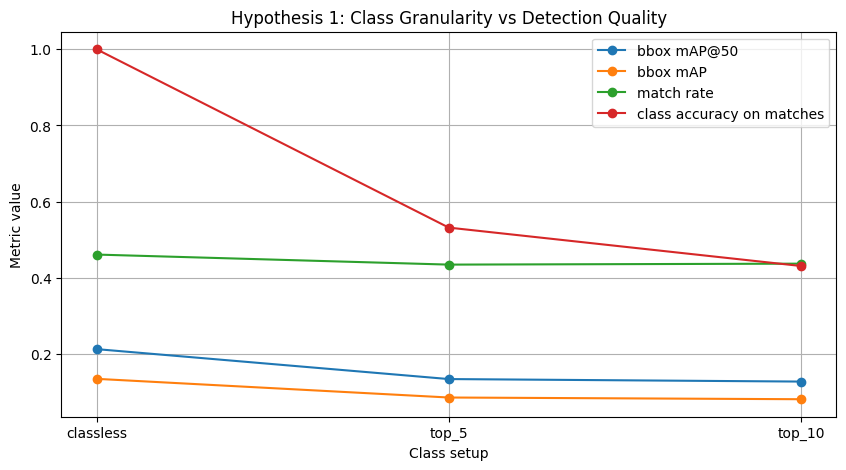

In [29]:
import matplotlib.pyplot as plt

plot_df = hyp1_summary.sort_values("num_classes")

plt.figure(figsize=(10, 5))
plt.plot(plot_df["mode"], plot_df["best_bbox_map_50"], marker="o", label="bbox mAP@50")
plt.plot(plot_df["mode"], plot_df["best_bbox_map"], marker="o", label="bbox mAP")
plt.plot(plot_df["mode"], plot_df["match_rate"], marker="o", label="match rate")
plt.plot(
    plot_df["mode"],
    plot_df["class_accuracy_on_matches"],
    marker="o",
    label="class accuracy on matches",
)

plt.xlabel("Class setup")
plt.ylabel("Metric value")
plt.title("Hypothesis 1: Class Granularity vs Detection Quality")
plt.legend()
plt.grid(True)
plt.show()

### Observations

The results support the hypothesis that increasing class granularity reduces detection quality.

- The classless model performs best, reaching `mAP@0.5 = 0.213`, compared with `0.134` for top-5 and `0.128`
for top-10.

- Localization changes relatively little: match rate decreases only from `0.461` to approximately `0.435`.
Therefore, localization alone does not explain the large mAP reduction.

- Classification accuracy on matched boxes drops sharply from 1.0 in the classless setup to 0.532 for
top-5 and 0.431 for top-10.

- Recall also declines as more classes are introduced: `mAR@100` falls from 0.311 to 0.239 and then 0.216.
- The number of predictions increases with class count, while images without matches also increase. This
suggests that finer classification produces more false positives rather than better coverage.

- Top-5 performs only moderately better than top-10. Reducing the taxonomy helps, but substantial
confusion remains even with five foreground classes.

- Every setup achieved its best result at epoch 7, so the comparison is not caused by different
convergence points.

In [ ]:
if not is_google_colab():
    !rclone copy ./taco_trash gdrive:taco_trash --progress
    !rclone copy checkpoints gdrive:taco_trash/checkpoints --progress

Transferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 69
Elapsed time:         0.5sTransferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 69
Elapsed time:         1.0sTransferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 75
Elapsed time:         1.5sTransferred:   	   18.730 KiB / 467.637 MiB, 0%, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 124
Transferred:            0 / 5, 0%
Elapsed time:         1.9s
Transferring:
 * hyp1_top_10_heads_8/ev…e-koi8cwif-main.1941.0:100% / 14.695 KiB, 0 B/s, -
 * checkpoints/hyp1_top_10_heads_8_best_model.pt:  0% / 233.809 MiB, 0 B/s, -
 *      checkpoints/hyp1_top_10_heads_8_eval.csv:100% / 4.035 KiB, 0 B/s, -
 * checkpoints/hyp1_top_10_heads_8_last_model.pt:  0% / 233.809 MiB, 0 B/s, -Transferred:   	    5.042 MiB / 467.637 MiB, 1%, 9.364 KiB/s, ETA 14h3m
Checks:                 0 / 0, -, Listed 124
Transferred:            

# Hypothesis 2: some classes are poison/noisy

This hypothesis tests whether particular classes disproportionately reduce classification and detection quality. Some categories may have very few examples, inconsistent annotations, high visual diversity, or strong visual similarity to other classes. These problematic classes can introduce ambiguous training signals and increase confusion across the entire label space.

The experiment analyses matched predictions using a trained model. For each class, it measures:

- Number of ground-truth instances and matched detections.
- Classification accuracy among geometrically matched boxes.
- Most frequent class confusions.
- Mean confidence and IoU of matched predictions.
- Classes that are frequently missed or incorrectly predicted.

If a small number of classes have consistently low classification accuracy, high confusion rates, or insufficient support, they can be considered candidates for merging, relabeling, or exclusion. This analysis separates class-specific annotation and taxonomy problems from general localization errors

In [ ]:
top_supercats = df["supercategory"].value_counts().head(10).index.tolist()
df_supercats = df.copy()
df_supercats["supercategory_reduced"] = df_supercats["supercategory"].where(
    df_supercats["supercategory"].isin(top_supercats),
    "Other",
)

label_values = sorted(df_supercats["supercategory_reduced"].unique())
label_map = {name: i + 1 for i, name in enumerate(label_values)}
num_classes = len(label_map) + 1

train_loader, val_loader = get_loaders(
    df=df_supercats,
    label_map=label_map,
    label_col="supercategory_reduced",
    train_transform=None,
    num_workers=2,
)

First, load the best model

In [ ]:
model = get_model(
  num_classes=num_classes,
  train_mode="all"
)

_ = load_checkpoint(
  path=os.path.join(ROOT_PATH, "taco_trash", "checkpoints",  "full_40_bbox_scheduler_max_top_10_categories_best_model.pt"),
  model=model,
  device=device,
)

In [ ]:
from collections import defaultdict, Counter
from torchvision.ops import box_iou
import pandas as pd
import torch


@torch.no_grad()
def collect_detection_confusions(
    model,
    dataloader,
    device,
    score_threshold=0.05,
    iou_threshold=0.5,
):
    model.eval()

    rows = []
    gt_counts = Counter()
    pred_counts = Counter()
    matched_gt_counts = Counter()
    correct_counts = Counter()
    confusion_counts = Counter()

    previous_score_thresh = model.roi_heads.score_thresh
    previous_detections_per_img = model.roi_heads.detections_per_img

    model.roi_heads.score_thresh = score_threshold
    model.roi_heads.detections_per_img = 100

    try:
        for batch_idx, (images, targets) in enumerate(tqdm(dataloader, total=len(dataloader))):
            images = [img.to(device) for img in images]

            outputs = model(images)

            for image_idx, (out, target) in enumerate(zip(outputs, targets)):
                pred_boxes = out["boxes"].detach().cpu()
                pred_scores = out["scores"].detach().cpu()
                pred_labels = out["labels"].detach().cpu()

                keep = pred_scores >= score_threshold
                pred_boxes = pred_boxes[keep]
                pred_scores = pred_scores[keep]
                pred_labels = pred_labels[keep]

                gt_boxes = target["boxes"].detach().cpu()
                gt_labels = target["labels"].detach().cpu()

                for label in gt_labels.tolist():
                    gt_counts[int(label)] += 1

                for label in pred_labels.tolist():
                    pred_counts[int(label)] += 1

                if len(gt_boxes) == 0 or len(pred_boxes) == 0:
                    continue

                ious = box_iou(pred_boxes, gt_boxes)

                used_pred = set()
                used_gt = set()

                while ious.numel() > 0:
                    max_iou = ious.max().item()
                    if max_iou < iou_threshold:
                        break

                    flat_idx = ious.argmax().item()
                    pred_idx = flat_idx // ious.shape[1]
                    gt_idx = flat_idx % ious.shape[1]

                    if pred_idx in used_pred or gt_idx in used_gt:
                        ious[pred_idx, gt_idx] = -1
                        continue

                    used_pred.add(pred_idx)
                    used_gt.add(gt_idx)

                    gt_label = int(gt_labels[gt_idx])
                    pred_label = int(pred_labels[pred_idx])
                    score = float(pred_scores[pred_idx])
                    iou = float(max_iou)

                    matched_gt_counts[gt_label] += 1
                    confusion_counts[(gt_label, pred_label)] += 1

                    if gt_label == pred_label:
                        correct_counts[gt_label] += 1

                    rows.append({
                        "batch_idx": batch_idx,
                        "image_idx": image_idx,
                        "gt_label": gt_label,
                        "pred_label": pred_label,
                        "score": score,
                        "iou": iou,
                        "correct": gt_label == pred_label,
                    })

                    ious[pred_idx, :] = -1
                    ious[:, gt_idx] = -1

    finally:
        model.roi_heads.score_thresh = previous_score_thresh
        model.roi_heads.detections_per_img = previous_detections_per_img

    matched_df = pd.DataFrame(rows)

    class_rows = []
    all_labels = sorted(set(gt_counts) | set(pred_counts))

    for label in all_labels:
        gt = gt_counts[label]
        pred = pred_counts[label]
        matched = matched_gt_counts[label]
        correct = correct_counts[label]

        class_rows.append({
            "label": label,
            "gt_count": gt,
            "pred_count": pred,
            "matched_gt_count": matched,
            "correct_count": correct,
            "recall_at_iou": matched / gt if gt > 0 else 0.0,
            "class_acc_on_matched": correct / matched if matched > 0 else 0.0,
            "pred_per_gt": pred / gt if gt > 0 else 0.0,
        })

    class_df = pd.DataFrame(class_rows)

    confusion_rows = []
    for (gt_label, pred_label), count in confusion_counts.items():
        confusion_rows.append({
            "gt_label": gt_label,
            "pred_label": pred_label,
            "count": count,
        })

    confusion_df = pd.DataFrame(confusion_rows)

    return matched_df, class_df, confusion_df

In [ ]:
matched_df, class_df, confusion_df = collect_detection_confusions(
    model=model,
    dataloader=val_loader,
    device=device,
    score_threshold=0.05,
    iou_threshold=0.5,
)

100%|██████████| 75/75 [01:50<00:00,  1.47s/it]


In [ ]:
id_to_name = {
    model_id: class_name
    for class_name, model_id in label_map.items()
}

class_df["class_name"] = class_df["label"].map(id_to_name)

confusion_df["gt_name"] = confusion_df["gt_label"].map(id_to_name)
confusion_df["pred_name"] = confusion_df["pred_label"].map(id_to_name)

## Worst classes

In [ ]:
class_df.sort_values(
    ["class_acc_on_matched", "recall_at_iou"],
    ascending=[True, True],
)

,label,gt_count,pred_count,matched_gt_count,correct_count,recall_at_iou,class_acc_on_matched,pred_per_gt
7,8,54,617,24,1,0.444444,0.041667,11.425926
5,6,42,274,21,4,0.500000,0.190476,6.523810
10,11,73,629,21,6,0.287671,0.285714,8.616438
8,9,125,983,73,21,0.584000,0.287671,7.864000
3,4,39,452,24,10,0.615385,0.416667,11.589744
6,7,153,1349,56,25,0.366013,0.446429,8.816993
4,5,88,499,19,9,0.215909,0.473684,5.670455
0,1,86,456,55,28,0.639535,0.509091,5.302326
2,3,58,295,30,17,0.517241,0.566667,5.086207
1,2,56,436,20,16,0.357143,0.800000,7.785714


## Classes with enough samples but bad classification

In [ ]:
class_df[
    class_df["gt_count"] >= 20
].sort_values("class_acc_on_matched")

,label,gt_count,pred_count,matched_gt_count,correct_count,recall_at_iou,class_acc_on_matched,pred_per_gt
7,8,54,617,24,1,0.444444,0.041667,11.425926
5,6,42,274,21,4,0.500000,0.190476,6.523810
10,11,73,629,21,6,0.287671,0.285714,8.616438
8,9,125,983,73,21,0.584000,0.287671,7.864000
3,4,39,452,24,10,0.615385,0.416667,11.589744
6,7,153,1349,56,25,0.366013,0.446429,8.816993
4,5,88,499,19,9,0.215909,0.473684,5.670455
0,1,86,456,55,28,0.639535,0.509091,5.302326
2,3,58,295,30,17,0.517241,0.566667,5.086207
1,2,56,436,20,16,0.357143,0.800000,7.785714


## Overpredicted classes

In [ ]:
class_df.sort_values("pred_per_gt", ascending=False)

,label,gt_count,pred_count,matched_gt_count,correct_count,recall_at_iou,class_acc_on_matched,pred_per_gt
9,10,22,291,8,7,0.363636,0.875000,13.227273
3,4,39,452,24,10,0.615385,0.416667,11.589744
7,8,54,617,24,1,0.444444,0.041667,11.425926
6,7,153,1349,56,25,0.366013,0.446429,8.816993
10,11,73,629,21,6,0.287671,0.285714,8.616438
8,9,125,983,73,21,0.584000,0.287671,7.864000
1,2,56,436,20,16,0.357143,0.800000,7.785714
5,6,42,274,21,4,0.500000,0.190476,6.523810
4,5,88,499,19,9,0.215909,0.473684,5.670455
0,1,86,456,55,28,0.639535,0.509091,5.302326


## Major confusions

In [ ]:
confusion_df[
    confusion_df["gt_label"] != confusion_df["pred_label"]
].sort_values("count", ascending=False).head(30)

,gt_label,pred_label,count
19,9,7,16
9,8,7,11
43,1,3,10
31,9,8,9
5,7,9,8
46,9,1,7
18,9,4,6
21,11,7,6
24,1,9,6
56,4,7,6


## Confusion matrix

In [ ]:
confusion_matrix = confusion_df.pivot_table(
    index="gt_label",
    columns="pred_label",
    values="count",
    fill_value=0,
    aggfunc="sum",
)
confusion_matrix

pred_label,1,2,3,4,5,6,7,8,9,10,11
gt_label,,,,,,,,,,,
1,28,0,10,4,0,1,2,3,6,0,1
2,0,16,1,0,0,0,1,2,0,0,0
3,3,1,17,1,0,1,2,1,4,0,0
4,1,0,3,10,0,0,6,1,1,1,1
5,0,0,1,0,9,0,2,6,0,0,1
6,4,0,4,0,0,4,4,4,1,0,0
7,1,2,4,4,1,4,25,5,8,1,1
8,2,0,0,0,2,0,11,1,1,2,5
9,7,0,6,6,1,2,16,9,21,0,5


## Save outputs

In [ ]:
class_df.to_csv(os.path.join(ROOT_PATH, "taco_trash", "class_diagnostics.csv"), index=False)
confusion_df.to_csv(os.path.join(ROOT_PATH, "taco_trash", "class_confusions.csv"), index=False)
matched_df.to_csv(os.path.join(ROOT_PATH, "taco_trash", "matched_predictions.csv"), index=False)

In [ ]:
from google.colab import files
files.download(os.path.join(ROOT_PATH, "taco_trash", "matched_predictions.csv"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
id_to_name = {
    model_id: class_name
    for class_name, model_id in label_map.items()
}

class_df["class_name"] = class_df["label"].map(id_to_name)
confusion_df["gt_name"] = confusion_df["gt_label"].map(id_to_name)
confusion_df["pred_name"] = confusion_df["pred_label"].map(id_to_name)

class_df.sort_values("class_acc_on_matched")

,label,gt_count,pred_count,matched_gt_count,correct_count,recall_at_iou,class_acc_on_matched,pred_per_gt,class_name
7,8,54,617,24,1,0.444444,0.041667,11.425926,Other plastic
5,6,42,274,21,4,0.500000,0.190476,6.523810,Cup
10,11,73,629,21,6,0.287671,0.285714,8.616438,Unlabeled litter
8,9,125,983,73,21,0.584000,0.287671,7.864000,Plastic bag & wrapper
3,4,39,452,24,10,0.615385,0.416667,11.589744,Carton
6,7,153,1349,56,25,0.366013,0.446429,8.816993,Other
4,5,88,499,19,9,0.215909,0.473684,5.670455,Cigarette
0,1,86,456,55,28,0.639535,0.509091,5.302326,Bottle
2,3,58,295,30,17,0.517241,0.566667,5.086207,Can
1,2,56,436,20,16,0.357143,0.800000,7.785714,Bottle cap


In [ ]:
confusion_df[
    confusion_df["gt_label"] != confusion_df["pred_label"]
].sort_values("count", ascending=False).head(15)

,gt_label,pred_label,count,gt_name,pred_name
19,9,7,16,Plastic bag & wrapper,Other
9,8,7,11,Other plastic,Other
43,1,3,10,Bottle,Can
31,9,8,9,Plastic bag & wrapper,Other plastic
5,7,9,8,Other,Plastic bag & wrapper
46,9,1,7,Plastic bag & wrapper,Bottle
18,9,4,6,Plastic bag & wrapper,Carton
21,11,7,6,Unlabeled litter,Other
24,1,9,6,Bottle,Plastic bag & wrapper
56,4,7,6,Carton,Other


In [ ]:
class_df[[
    "class_name",
    "gt_count",
    "pred_count",
    "matched_gt_count",
    "correct_count",
    "recall_at_iou",
    "class_acc_on_matched",
    "pred_per_gt",
]].sort_values("class_acc_on_matched")

,class_name,gt_count,pred_count,matched_gt_count,correct_count,recall_at_iou,class_acc_on_matched,pred_per_gt
7,Other plastic,54,617,24,1,0.444444,0.041667,11.425926
5,Cup,42,274,21,4,0.500000,0.190476,6.523810
10,Unlabeled litter,73,629,21,6,0.287671,0.285714,8.616438
8,Plastic bag & wrapper,125,983,73,21,0.584000,0.287671,7.864000
3,Carton,39,452,24,10,0.615385,0.416667,11.589744
6,Other,153,1349,56,25,0.366013,0.446429,8.816993
4,Cigarette,88,499,19,9,0.215909,0.473684,5.670455
0,Bottle,86,456,55,28,0.639535,0.509091,5.302326
2,Can,58,295,30,17,0.517241,0.566667,5.086207
1,Bottle cap,56,436,20,16,0.357143,0.800000,7.785714


### Conclusion

The model does not fail only because of localization.
A large part of the mAP loss comes from class confusion.
Several classes are visually/semantically too close or too noisy for the current top-10 setup.

We matched predictions to ground-truth boxes at IoU >= 0.5 and measured class accuracy on matched boxes.
The analysis showed that several classes have very low class accuracy despite having matched boxes. For
example, label 8 has 24 matched boxes but only 1 correct class prediction, giving class accuracy 0.042.
Labels 6, 9, and 11 also show low class accuracy. The most common confusions are label 9 -> 7, label 8
-> 7, and label 1 -> 3.

This supports the hypothesis that class granularity/noise is a bottleneck. Reducing or merging ambiguous classes should improve detection mAP.

# Hypothesis 3: sampler is worsening class confusion

## Motivation

After confirming in Hypothesis 2 that class confusion is the dominant failure mode,
the next question is: **does `WeightedRandomSampler` make it worse?**

`WeightedRandomSampler` oversamples rare classes so the model sees them more often.
The concern is that oversampling minority classes forces the model to encounter unusual
class co-occurrences and imbalanced batch compositions that wouldn't appear in real
inference conditions — potentially increasing confusion between visually similar but
frequency-imbalanced classes (e.g. *Plastic bag* vs *Other*).

## Result

`WeightedRandomSampler` produced marginally **higher** mAP@50, match rate, and class
accuracy on matched boxes across all 5 epochs.

**Hypothesis rejected.** The sampler does not increase class confusion.
The weighted sampler is retained for all subsequent experiments.

## What this means

The class confusion identified in Hypampling strategy.
The root cause lies in the class taxothe visual ambiguity
between semantically overlapping cate plastic*,
*Plastic bag & wrapper*). Fixing the s the correct next step.

Modify `get_loaders()`

In [ ]:
def get_loaders(
    df,
    label_map,
    label_col="supercategory_reduced",
    train_transform=None,
    return_masks=True,
    use_original_boxes=True,
    batch_size_train=1,
    batch_size_val=1,
    num_workers=2,
    pin_memory=False,
    use_weighted_sampler=True,
):
    base_dataset = TacoDatasetOriginalBoxes(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=None,
        return_masks=return_masks,
        use_original_boxes=use_original_boxes,
    )

    train_size = int(0.8 * len(base_dataset))
    val_size = len(base_dataset) - train_size

    train_indices, val_indices = torch.utils.data.random_split(
        range(len(base_dataset)),
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42),
    )

    train_dataset_full = TacoDatasetOriginalBoxes(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=train_transform,
        return_masks=return_masks,
        use_original_boxes=use_original_boxes,
    )

    val_dataset_full = TacoDatasetOriginalBoxes(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=None,
        return_masks=return_masks,
        use_original_boxes=use_original_boxes,
    )

    train_dataset = Subset(train_dataset_full, train_indices.indices)
    val_dataset = Subset(val_dataset_full, val_indices.indices)

    sampler = None
    shuffle = True

    if use_weighted_sampler:
        class_counts = Counter()

        for dataset_idx in train_indices.indices:
            _, group = base_dataset.image_groups[dataset_idx]

            labels = [
                label_map[value]
                for value in group[label_col].tolist()
            ]

            class_counts.update(labels)

        class_weights = {
            cls: 1.0 / np.sqrt(count)
            for cls, count in class_counts.items()
        }

        sample_weights = []

        for dataset_idx in train_indices.indices:
            _, group = base_dataset.image_groups[dataset_idx]

            labels = [
                label_map[value]
                for value in group[label_col].tolist()
            ]

            weight = max(class_weights[label] for label in labels)
            sample_weights.append(weight)

        sample_weights = torch.DoubleTensor(sample_weights)

        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True,
        )

        shuffle = False

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size_train,
        sampler=sampler,
        shuffle=shuffle,
        collate_fn=collate_fn,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=False,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size_val,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=False,
    )

    return train_loader, val_loader

In [ ]:
train_loader_sampler, val_loader = get_loaders(
    df=df_supercats,
    label_map=label_map,
    label_col="supercategory_reduced",
    train_transform=None,
    return_masks=True,
    use_original_boxes=True,
    batch_size_train=1,
    batch_size_val=1,
    num_workers=2,
    pin_memory=False,
    use_weighted_sampler=True,
)

In [ ]:
train_loader_no_sampler, val_loader = get_loaders(
    df=df_supercats,
    label_map=label_map,
    label_col="supercategory_reduced",
    train_transform=None,
    return_masks=True,
    use_original_boxes=True,
    batch_size_train=1,
    batch_size_val=1,
    num_workers=2,
    pin_memory=False,
    use_weighted_sampler=False,
)

## Train model

### Sampler, 5 epochs

In [ ]:
num_epochs = 5
run_prefix = f"sampler_test_{num_epochs}_epochs"
model = get_model(num_classes=num_classes, train_mode="heads")

optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-3,
    momentum=0.9,
    weight_decay=0.0005,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
)

history_sampler = train_model(
    model=model,
    train_loader=train_loader_sampler,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=torch.amp.GradScaler("cuda"),
    writer=SummaryWriter(log_dir=os.path.join(DEFAULT_RUNS_PATH, f"runs/{run_prefix}")),
    num_epoch=num_epochs,
    run_prefix=run_prefix,
    device=device,
    eval_every=1,
    checkpoint_score_fn=score_by_eval_bbox_map_50,
    scheduler_step_fn=step_on_val_bbox_map_50,
    id_to_name=id_to_name,
    metrics_csv_paths={
        'train': os.path.join(DEFAULT_RUNS_PATH, f'{run_prefix}_train.csv'),
        'eval': os.path.join(DEFAULT_RUNS_PATH, f'{run_prefix}_eval.csv')
    },
)

Epoch 1. Train: 100%|██████████| 1200/1200 [09:41<00:00,  2.06it/s]
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)
Train model. Epoch 5: 100%|██████████| 5/5 [1:57:25<00:00, 1409.04s/it]


## No sampler, 5 epochs

In [ ]:
num_epochs = 5
run_prefix = f"no_sampler_test_{num_epochs}_epochs"
model = get_model(num_classes=num_classes, train_mode="heads")

optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-3,
    momentum=0.9,
    weight_decay=0.0005,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
)

history_sampler = train_model(
    model=model,
    train_loader=train_loader_no_sampler,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=torch.amp.GradScaler("cuda"),
    writer=SummaryWriter(log_dir=os.path.join(DEFAULT_RUNS_PATH, f"runs/{run_prefix}")),
    num_epoch=num_epochs,
    run_prefix=run_prefix,
    device=device,
    eval_every=1,
    checkpoint_score_fn=score_by_eval_bbox_map_50,
    scheduler_step_fn=step_on_val_bbox_map_50,
    id_to_name=id_to_name,
    metrics_csv_paths={
        'train': os.path.join(DEFAULT_RUNS_PATH, f'{run_prefix}_train.csv'),
        'eval': os.path.join(DEFAULT_RUNS_PATH, f'{run_prefix}_eval.csv')
    },
)

Train model. Epoch 5: 100%|██████████| 5/5 [1:55:26<00:00, 1385.30s/it]


## Visualize

In [30]:
no_sampler_path = os.path.join(DEFAULT_RUNS_PATH, 'no_sampler_test_5_epochs_eval.csv')
sampler_path = os.path.join(DEFAULT_RUNS_PATH, 'sampler_test_5_epochs_eval.csv')

sampler_df = pd.read_csv(no_sampler_path)
no_sampler_df = pd.read_csv(sampler_path)
sampler_df["run"] = "weighted_sampler"
no_sampler_df["run"] = "no_sampler"

compare_df = pd.concat([sampler_df, no_sampler_df], ignore_index=True)

### Best metric summary

In [31]:
def best_summary(df, run_name):
    best_idx = df["eval/bbox_map_50"].idxmax()
    row = df.loc[best_idx]

    return {
        "run": run_name,
        "best_epoch": row["epoch"],
        "bbox_map_50": row["eval/bbox_map_50"],
        "bbox_map": row["eval/bbox_map"],
        "bbox_mar_100": row["eval/bbox_mar_100"],
        "match_rate": row["eval/match_rate"],
        "class_accuracy_on_matches": row["eval/class_accuracy_on_matches"],
        "pred_instances": row["eval/pred_instances"],
        "mean_unmatched_score": row["eval/mean_unmatched_score"],
    }

summary_df = pd.DataFrame([
    best_summary(sampler_df, "weighted_sampler"),
    best_summary(no_sampler_df, "no_sampler"),
])

summary_df

,run,best_epoch,bbox_map_50,bbox_map,bbox_mar_100,match_rate,class_accuracy_on_matches,pred_instances,mean_unmatched_score
0,weighted_sampler,4,0.129569,0.083091,0.21242,0.415829,0.416918,5199.0,0.173862
1,no_sampler,4,0.139015,0.087744,0.21620,0.422111,0.437500,5258.0,0.173861


### Target metrics

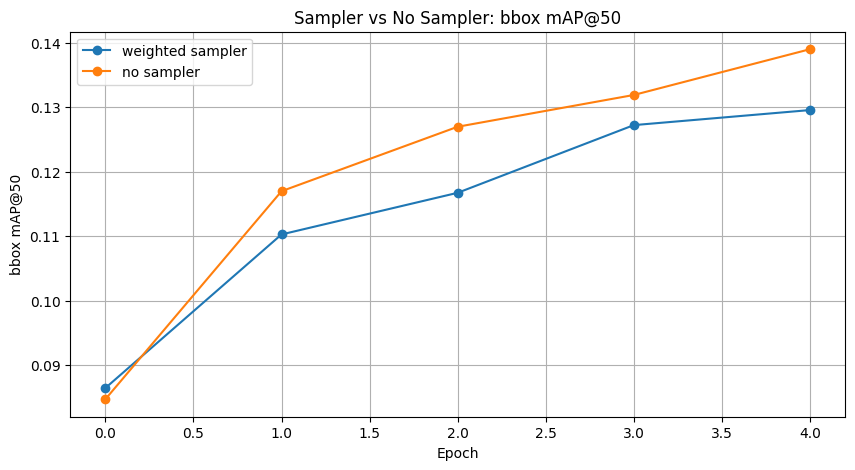

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    sampler_df["epoch"],
    sampler_df["eval/bbox_map_50"],
    marker="o",
    label="weighted sampler",
)

plt.plot(
    no_sampler_df["epoch"],
    no_sampler_df["eval/bbox_map_50"],
    marker="o",
    label="no sampler",
)

plt.xlabel("Epoch")
plt.ylabel("bbox mAP@50")
plt.title("Sampler vs No Sampler: bbox mAP@50")
plt.legend()
plt.grid(True)
plt.show()

### Class confusion metrics

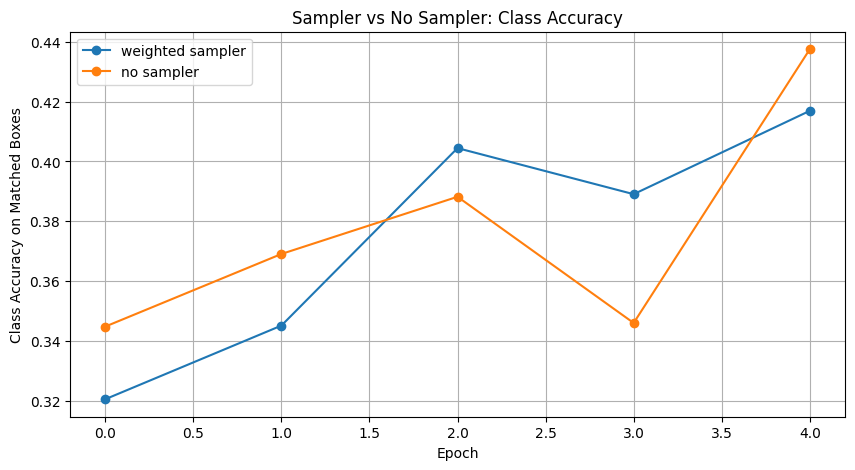

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    sampler_df["epoch"],
    sampler_df["eval/class_accuracy_on_matches"],
    marker="o",
    label="weighted sampler",
)

plt.plot(
    no_sampler_df["epoch"],
    no_sampler_df["eval/class_accuracy_on_matches"],
    marker="o",
    label="no sampler",
)

plt.xlabel("Epoch")
plt.ylabel("Class Accuracy on Matched Boxes")
plt.title("Sampler vs No Sampler: Class Accuracy")
plt.legend()
plt.grid(True)
plt.show()

#### Recall/matching

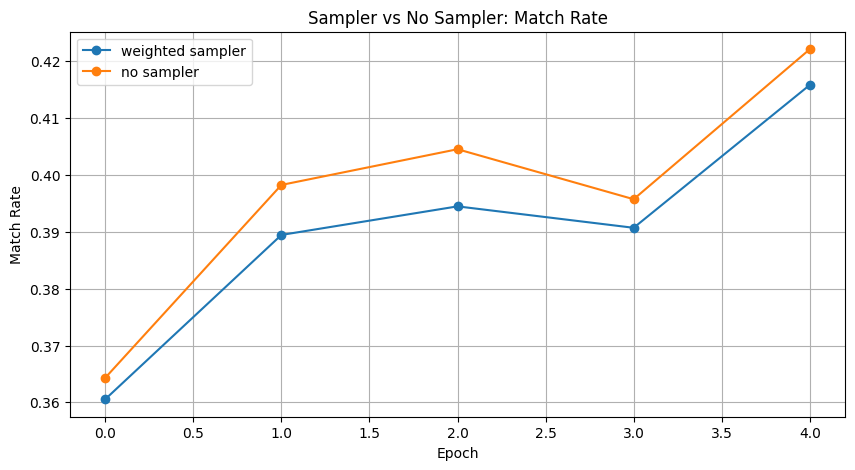

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    sampler_df["epoch"],
    sampler_df["eval/match_rate"],
    marker="o",
    label="weighted sampler",
)

plt.plot(
    no_sampler_df["epoch"],
    no_sampler_df["eval/match_rate"],
    marker="o",
    label="no sampler",
)

plt.xlabel("Epoch")
plt.ylabel("Match Rate")
plt.title("Sampler vs No Sampler: Match Rate")
plt.legend()
plt.grid(True)
plt.show()

### False-positive pressure

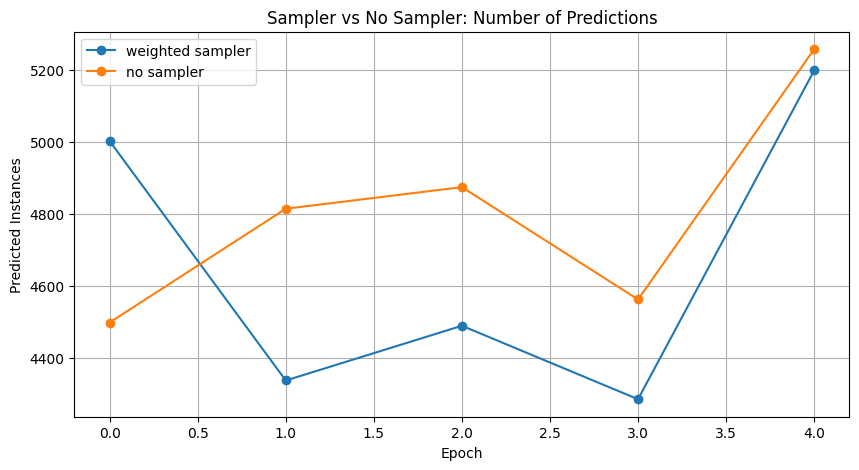

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    sampler_df["epoch"],
    sampler_df["eval/pred_instances"],
    marker="o",
    label="weighted sampler",
)

plt.plot(
    no_sampler_df["epoch"],
    no_sampler_df["eval/pred_instances"],
    marker="o",
    label="no sampler",
)

plt.xlabel("Epoch")
plt.ylabel("Predicted Instances")
plt.title("Sampler vs No Sampler: Number of Predictions")
plt.legend()
plt.grid(True)
plt.show()

## Observations

We tested whether WeightedRandomSampler increases class confusion by comparing two 5-epoch heads-only
Mask R-CNN runs with identical settings except sampling. The weighted sampler produced slightly higher
bbox mAP@0.5, match rate, and class accuracy on matched boxes. Therefore, this experiment does not
support the hypothesis that the sampler worsens class confusion. We keep the weighted sampler for
further experiments.

What this means next:

Sampler is not the main problem.
Class granularity/noisy class definitions remain the stronger explanation.

# Hypothesis 4: the model needs fewer categories, not more epochs

This hypothesis tests whether detection quality is limited by category complexity rather than insufficient training time. If classification between visually similar or underrepresented categories is the main bottleneck, training the same taxonomy for additional epochs may reduce training loss without meaningfully improving validation mAP@0.5.

To test this, models with fewer categories are compared under the same data split, architecture, and training configuration. Their validation performance is evaluated using bbox_map_50, bbox_map, recall, match rate, and classification accuracy on geometrically matched detections.

The hypothesis is supported if a reduced-category model achieves better validation metrics within fewer epochs than the full-category model achieves after longer training. This would indicate that simplifying or restructuring the label taxonomy is more effective than extending training.

In [21]:
def make_reduced_supercategory_df(
    df: pd.DataFrame,
    top_k: int | None = None,
    classless: bool = False,
) -> tuple[pd.DataFrame, dict[object, int], int, dict[int, object]]:
    """Create labels for a reduced-category detection experiment.

    Args:
        df (pd.DataFrame): Object-level annotations containing a
            ``supercategory`` column.
        top_k (int | None): Number of most frequent supercategories to
            retain. Remaining categories are assigned to ``Other``.
        classless (bool): Whether to collapse all objects into one
            foreground class named ``litter``.

    Returns:
        tuple[pd.DataFrame, dict[object, int], int, dict[int, object]]:
            The relabeled dataframe, label-to-ID mapping, total model
            class count including background, and reverse ID mapping.

    Raises:
        ValueError: If ``top_k`` is not provided for a non-classless run.
    """
    if not classless and top_k is None:
        raise ValueError("top_k must be provided when classless=False")

    # Work on a copy so the source annotations remain identical across runs.
    df_reduced = df.copy()

    if classless:
        # Remove classification difficulty while retaining every object instance.
        df_reduced["label_reduced"] = "litter"
        label_values = ["litter"]
    else:
        # Keep frequent classes separate and merge the long tail into Other.
        top_supercats = (
            df_reduced["supercategory"]
            .value_counts()
            .head(top_k)
            .index
            .tolist()
        )

        df_reduced["label_reduced"] = df_reduced["supercategory"].where(
            df_reduced["supercategory"].isin(top_supercats),
            "Other",
        )

        label_values = sorted(df_reduced["label_reduced"].unique())

    # Class ID 0 is reserved for the detector's background class.
    label_map = {
        name: i + 1
        for i, name in enumerate(label_values)
    }

    num_classes = len(label_map) + 1

    # Use the reverse mapping for readable per-class evaluation metrics.
    id_to_name = {
        model_id: class_name
        for class_name, model_id in label_map.items()
    }

    return df_reduced, label_map, num_classes, id_to_name

In [17]:
from collections import Counter
from typing import Any
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler


def get_loaders_original_boxes(
    df: pd.DataFrame,
    label_map: dict[object, int],
    label_col: str = "label_reduced",
    train_transform: Any | None = None,
    return_masks: bool = True,
    use_original_boxes: bool = True,
    batch_size_train: int = 1,
    batch_size_val: int = 1,
    num_workers: int = 2,
    pin_memory: bool = False,
    use_weighted_sampler: bool = True,
) -> tuple[DataLoader, DataLoader]:
    """Build deterministic train and validation loaders for the experiment.

    Args:
        df (pd.DataFrame): Relabeled object-level annotations.
        label_map (dict[object, int]): Mapping from dataframe labels to
            contiguous detector class IDs.
        label_col (str): Dataframe column containing training labels.
        train_transform (Any | None): Optional transform applied only to
            training images and targets.
        return_masks (bool): Whether dataset targets include instance masks.
        use_original_boxes (bool): Whether to use annotation bounding boxes
            instead of deriving boxes from masks.
        batch_size_train (int): Number of training images per batch.
        batch_size_val (int): Number of validation images per batch.
        num_workers (int): Number of worker processes for each loader.
        pin_memory (bool): Whether loaders copy tensors into pinned memory.
        use_weighted_sampler (bool): Whether to oversample images containing
            underrepresented classes.

    Returns:
        tuple[DataLoader, DataLoader]: Training and validation loaders that
            share the same deterministic 80/20 image split.
    """
    # This transform-free dataset supplies stable metadata for splitting and weights.
    base_dataset = TacoDatasetOriginalBoxes(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=None,
        return_masks=return_masks,
        use_original_boxes=use_original_boxes,
    )

    train_size = int(0.8 * len(base_dataset))
    val_size = len(base_dataset) - train_size

    # Reuse a fixed seed so category-count experiments use comparable images.
    train_indices, val_indices = torch.utils.data.random_split(
        range(len(base_dataset)),
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42),
    )

    # Separate dataset objects prevent training transforms from affecting validation.
    train_dataset_full = TacoDatasetOriginalBoxes(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=train_transform,
        return_masks=return_masks,
        use_original_boxes=use_original_boxes,
    )

    val_dataset_full = TacoDatasetOriginalBoxes(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=None,
        return_masks=return_masks,
        use_original_boxes=use_original_boxes,
    )

    train_dataset = Subset(train_dataset_full, train_indices.indices)
    val_dataset = Subset(val_dataset_full, val_indices.indices)

    sampler = None
    shuffle = True

    if use_weighted_sampler:
        # Count object labels only in the training split to avoid validation leakage.
        class_counts = Counter()

        for dataset_idx in train_indices.indices:
            _, group = base_dataset.image_groups[dataset_idx]
            labels = [label_map[value] for value in group[label_col].tolist()]
            class_counts.update(labels)

        # Square-root inverse frequency limits extreme oversampling of rare classes.
        class_weights = {
            cls: 1.0 / np.sqrt(count)
            for cls, count in class_counts.items()
        }

        sample_weights = []

        # Assign an image the largest weight among the classes it contains.
        for dataset_idx in train_indices.indices:
            _, group = base_dataset.image_groups[dataset_idx]
            labels = [label_map[value] for value in group[label_col].tolist()]
            weight = max(class_weights[label] for label in labels)
            sample_weights.append(weight)

        sampler = WeightedRandomSampler(
            weights=torch.DoubleTensor(sample_weights),
            num_samples=len(sample_weights),
            replacement=True,
        )

        # DataLoader forbids enabling shuffle together with an explicit sampler.
        shuffle = False

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size_train,
        sampler=sampler,
        shuffle=shuffle,
        collate_fn=collate_fn,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=False,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size_val,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=False,
    )

    return train_loader, val_loader

In [ ]:
def run_category_count_experiment(
    df: pd.DataFrame,
    top_k: int | None,
    run_prefix: str,
    num_epochs: int = 5,
    classless: bool = False,
) -> dict[str, Any]:
    """Train one short category-count experiment with Mask R-CNN heads.

    Args:
        df (pd.DataFrame): Original object-level annotation dataframe.
        top_k (int | None): Number of supercategories to preserve, or
            ``None`` for a classless experiment.
        run_prefix (str): Unique name used for logs, CSV files, and checkpoints.
        num_epochs (int): Number of training epochs.
        classless (bool): Whether to train a single-foreground-class model.

    Returns:
        dict[str, Any]: Training history and label metadata required to
            interpret the experiment artifacts.
    """
    # Construct the taxonomy before creating targets and prediction heads.
    df_exp, label_map_exp, num_classes_exp, id_to_name_exp = make_reduced_supercategory_df(
        df=df,
        top_k=top_k,
        classless=classless,
    )

    # Keep loader settings fixed so class count is the primary changed variable.
    train_loader_exp, val_loader_exp = get_loaders_original_boxes(
        df=df_exp,
        label_map=label_map_exp,
        label_col="label_reduced",
        train_transform=None,
        return_masks=True,
        use_original_boxes=True,
        batch_size_train=2,
        batch_size_val=2,
        num_workers=4,
        pin_memory=False,
        use_weighted_sampler=True,
    )

    # Train detection heads only to obtain a low-cost comparison.
    model_exp = get_model(
        num_classes=num_classes_exp,
        train_mode="heads",
    )

    optimizer_exp = torch.optim.SGD(
        [p for p in model_exp.parameters() if p.requires_grad],
        lr=1e-3,
        momentum=0.9,
        weight_decay=0.0005,
    )

    # Schedule learning rate according to the primary validation metric.
    scheduler_exp = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_exp,
        mode="max",
        factor=0.5,
        patience=2,
        threshold=1e-4,
        min_lr=1e-5,
    )

    scaler_exp = torch.amp.GradScaler("cuda")

    writer_exp = SummaryWriter(
        log_dir=os.path.join(DEFAULT_RUNS_PATH, f"runs/{run_prefix}")
    )

    # Evaluate every epoch because these diagnostic runs are intentionally short.
    history_exp = train_model(
        model=model_exp,
        train_loader=train_loader_exp,
        val_loader=val_loader_exp,
        optimizer=optimizer_exp,
        scheduler=scheduler_exp,
        scaler=scaler_exp,
        writer=writer_exp,
        num_epoch=num_epochs,
        run_prefix=run_prefix,
        device=device,
        eval_every=1,
        metrics_csv_paths={
            "train": os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix}_train.csv"),
            "eval": os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix}_eval.csv"),
        },
        checkpoint_score_fn=score_by_eval_bbox_map_50,
        scheduler_step_fn=step_on_val_bbox_map_50,
        id_to_name=id_to_name_exp,
    )

    return {
        "history": history_exp,
        "label_map": label_map_exp,
        "num_classes": num_classes_exp,
        "id_to_name": id_to_name_exp,
    }

### Top-10 categories

In [ ]:
exp_top10 = run_category_count_experiment(
    df=df,
    top_k=10,
    run_prefix="hyp4_top10_heads_5",
    num_epochs=5,
    classless=False,
)

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /home/ubuntu/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:02<00:00, 68.4MB/s] 
Epoch 1. Train: 100%|██████████| 600/600 [06:08<00:00,  1.63it/s]
/home/ubuntu/.local/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)
Epoch 2. Train: 100%|██████████| 600/600 [07:04<00:00,  1.41it/s]7s/it]
/home/ubuntu/.local/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)
Epoch 3. Train: 100%|██████████| 600/600 [08:11<00:00,  1.22it/s]/it]  
/home/ubuntu/.local/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore met

### Top-5 categories

In [ ]:
exp_top5 = run_category_count_experiment(
    df=df,
    top_k=5,
    run_prefix="hyp4_top5_heads_5",
    num_epochs=5,
    classless=False,
)

Epoch 1. Train: 100%|██████████| 600/600 [07:31<00:00,  1.33it/s]
/home/ubuntu/.local/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)
Epoch 2. Train: 100%|██████████| 600/600 [07:21<00:00,  1.36it/s]9s/it]
/home/ubuntu/.local/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)
Epoch 3. Train: 100%|██████████| 600/600 [07:18<00:00,  1.37it/s]/it]  
/home/ubuntu/.local/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will 

### Classless category

In [ ]:
exp_classless = run_category_count_experiment(
    df=df,
    top_k=None,
    run_prefix="hyp4_classless_heads_5",
    num_epochs=5,
    classless=True,
)

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /home/ubuntu/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 240MB/s]  
Epoch 1. Train: 100%|██████████| 600/600 [03:59<00:00,  2.50it/s]
/home/ubuntu/.local/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)
Epoch 2. Train: 100%|██████████| 600/600 [03:54<00:00,  2.56it/s]it]
/home/ubuntu/.local/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)
Epoch 3. Train: 100%|██████████| 600/600 [03:33<00:00,  2.80it/s]it]
/home/ubuntu/.local/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric cu

In [ ]:
!rclone copy ./taco_trash gdrive:taco_trash --progress
!rclone copy checkpoints gdrive:taco_trash/checkpoints --progress

Transferred:   	    3.377 KiB / 3.377 KiB, 100%, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 57
Transferred:            0 / 2, 0%
Elapsed time:         0.5s
Transferring:
 *               hyp4_classless_heads_5_eval.csv:100% / 2.666 KiB, 0 B/s, -
 *              hyp4_classless_heads_5_train.csv:100% / 728 B, 0 B/s, -Transferred:   	    3.377 KiB / 3.377 KiB, 100%, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 90
Transferred:            0 / 2, 0%
Elapsed time:         1.0s
Transferring:
 *               hyp4_classless_heads_5_eval.csv:100% / 2.666 KiB, 0 B/s, -
 *              hyp4_classless_heads_5_train.csv:100% / 728 B, 0 B/s, -Transferred:   	   12.600 KiB / 12.600 KiB, 100%, 3.376 KiB/s, ETA 0s
Checks:                 0 / 0, -, Listed 92
Transferred:            2 / 3, 67%
Elapsed time:         1.4s
Transferring:
 * runs/hyp4_classless_he…e-uq1nu765-main.1299.0:100% / 9.223 KiB, 0 B/s, -Transferred:   	   12.600 KiB / 12.600 KiB, 100%, 6.299 KiB/s, ETA 0s
Checks:  

### Compare results

In [ ]:
def summarize_eval_csv(path: str, run_name: str) -> dict[str, Any]:
    """Extract metrics from the best bbox mAP@0.5 epoch of one run.

    Args:
        path (str): Path to the validation metrics CSV file.
        run_name (str): Human-readable configuration name for the summary.

    Returns:
        dict[str, Any]: Run name and metrics recorded at its best validation
            bbox mAP@0.5 epoch.

    Raises:
        ValueError: If the metrics file is empty.
    """
    df_eval = pd.read_csv(path)
    if df_eval.empty:
        raise ValueError(f"Evaluation metrics file is empty: {path}")

    # Select all comparison metrics from one coherent checkpoint/epoch.
    best_idx = df_eval["eval/bbox_map_50"].idxmax()
    row = df_eval.loc[best_idx]

    return {
        "run": run_name,
        "best_epoch": row["epoch"],
        "bbox_map_50": row["eval/bbox_map_50"],
        "bbox_map": row["eval/bbox_map"],
        "bbox_mar_100": row["eval/bbox_mar_100"],
        "match_rate": row["eval/match_rate"],
        "class_accuracy_on_matches": row["eval/class_accuracy_on_matches"],
        "pred_instances": row["eval/pred_instances"],
        "mean_unmatched_score": row["eval/mean_unmatched_score"],
    }


hyp4_summary = pd.DataFrame([
    summarize_eval_csv(
        os.path.join(DEFAULT_RUNS_PATH, "hyp4_top10_heads_5_eval.csv"),
        "top10",
    ),
    summarize_eval_csv(
        os.path.join(DEFAULT_RUNS_PATH, "hyp4_top5_heads_5_eval.csv"),
        "top5",
    ),
    summarize_eval_csv(
        os.path.join(DEFAULT_RUNS_PATH, "hyp4_classless_heads_5_eval.csv"),
        "classless",
    ),
])

hyp4_summary

,run,best_epoch,bbox_map_50,bbox_map,bbox_mar_100,match_rate,class_accuracy_on_matches,pred_instances,mean_unmatched_score
0,top10,4,0.118244,0.077485,0.213100,0.405779,0.374613,4394.0,0.146186
1,top5,4,0.124204,0.082316,0.228713,0.415829,0.480363,5110.0,0.180131
2,classless,4,0.202376,0.133213,0.310804,0.444724,1.000000,5176.0,0.221299


## Visualize

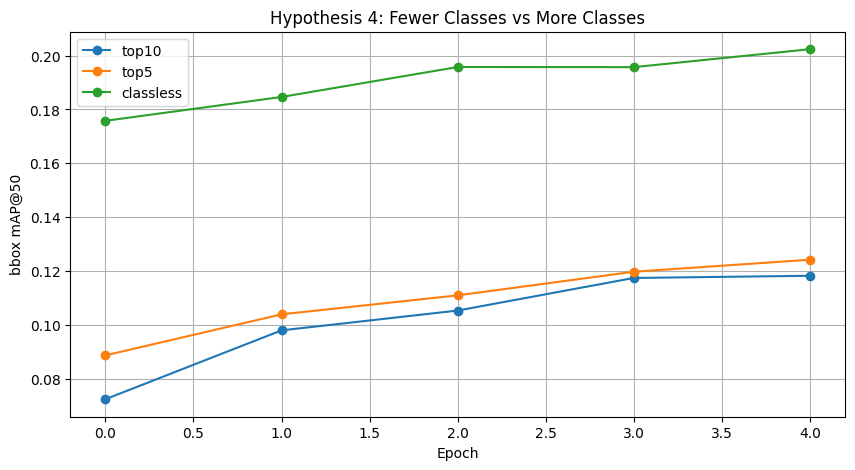

In [ ]:
plt.figure(figsize=(10, 5))

for run_name in ["top10", "top5", "classless"]:
    path = os.path.join(DEFAULT_RUNS_PATH, f"hyp4_{run_name}_heads_5_eval.csv")
    df_eval = pd.read_csv(path)
    plt.plot(
        df_eval["epoch"],
        df_eval["eval/bbox_map_50"],
        marker="o",
        label=run_name,
    )

plt.xlabel("Epoch")
plt.ylabel("bbox mAP@50")
plt.title("Hypothesis 4: Fewer Classes vs More Classes")
plt.legend()
plt.grid(True)
plt.show()

## Observations

The results support the hypothesis that category complexity is a stronger limitation than short training duration. After only five epochs, the classless model achieved the highest bbox_map_50 (`0.202`) substantially outperforming top-5 (`0.124`) and top-10 (`0.118`).

Localization changed less dramatically: match rate ranged from `0.406` for top-10 to `0.445` for the classless model. In contrast, classification accuracy on matched detections fell from `1.0` for classless detection to `0.480` for top-5 and `0.375` for top-10. This indicates that many objects are approximately localized but assigned an incorrect class.

Reducing the taxonomy from top-10 to top-5 provides only a modest improvement. The large classless advantage shows that classification ambiguity remains the primary bottleneck. However, this experiment alone does not fully prove that additional epochs are ineffective; that requires comparison with a longer top-10 run under the same split and configuration.


# Hypothesis 5: original bbox vs mask-derived bbox matters

This hypothesis tests whether the source of ground-truth bounding boxes affects detection quality. The dataset provides original bounding-box annotations, but boxes can also be reconstructed as the smallest rectangles enclosing the corresponding segmentation masks. Differences between these representations may introduce inconsistent training targets.

Two models are trained under identical conditions:

- Original boxes: bounding boxes are read directly from the dataset annotations.
- Mask-derived boxes: bounding boxes are calculated from the minimum and maximum coordinates of each
instance mask.

The configurations are compared using bbox_map_50, bbox_map, recall, match rate, and classification accuracy on matched detections. If one representation consistently performs better, it indicates that bounding-box construction affects localization quality. Similar results would suggest that box source is not a major performance bottleneck.

In [ ]:
def get_loaders_for_bbox_ablation(
    df: pd.DataFrame,
    label_map: dict[object, int],
    label_col: str = "supercategory_reduced",
    use_original_boxes: bool = True,
    return_masks: bool = True,
    batch_size_train: int = 3,
    batch_size_val: int = 3,
    num_workers: int = 6,
    pin_memory: bool = False,
) -> tuple[DataLoader, DataLoader]:
    """Build loaders for a controlled bounding-box source ablation.

    Args:
        df (pd.DataFrame): Object-level annotations used by both runs.
        label_map (dict[object, int]): Mapping from dataframe labels to
            contiguous detector class IDs.
        label_col (str): Dataframe column containing the training labels.
        use_original_boxes (bool): Whether targets use annotated boxes. If
            ``False``, boxes are derived from instance-mask extents.
        return_masks (bool): Whether targets include instance masks.
        batch_size_train (int): Number of training images per batch.
        batch_size_val (int): Number of validation images per batch.
        num_workers (int): Number of worker processes for each loader.
        pin_memory (bool): Whether loaders copy tensors into pinned memory.

    Returns:
        tuple[DataLoader, DataLoader]: Training and validation loaders with
            an identical deterministic image split.
    """
    # Build metadata with the same bbox source used by the actual loaders.
    base_dataset = TacoDatasetOriginalBoxes(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=None,
        return_masks=return_masks,
        use_original_boxes=use_original_boxes,
    )

    train_size = int(0.8 * len(base_dataset))
    val_size = len(base_dataset) - train_size

    # Fix the split so bbox construction is the only experimental variable.
    train_indices, val_indices = torch.utils.data.random_split(
        range(len(base_dataset)),
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42),
    )

    # No augmentation is applied in either run to avoid geometric confounding.
    train_dataset_full = TacoDatasetOriginalBoxes(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=None,
        return_masks=return_masks,
        use_original_boxes=use_original_boxes,
    )

    val_dataset_full = TacoDatasetOriginalBoxes(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=None,
        return_masks=return_masks,
        use_original_boxes=use_original_boxes,
    )

    train_dataset = Subset(train_dataset_full, train_indices.indices)
    val_dataset = Subset(val_dataset_full, val_indices.indices)

    # Compute sampler statistics from training annotations only.
    class_counts = Counter()

    for dataset_idx in train_indices.indices:
        _, group = base_dataset.image_groups[dataset_idx]
        labels = [label_map[value] for value in group[label_col].tolist()]
        class_counts.update(labels)

    # Moderate imbalance with inverse square-root class frequencies.
    class_weights = {
        cls: 1.0 / np.sqrt(count)
        for cls, count in class_counts.items()
    }

    sample_weights = []

    # Weight each image by its rarest contained class.
    for dataset_idx in train_indices.indices:
        _, group = base_dataset.image_groups[dataset_idx]
        labels = [label_map[value] for value in group[label_col].tolist()]
        weight = max(class_weights[label] for label in labels)
        sample_weights.append(weight)

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size_train,
        sampler=sampler,
        collate_fn=collate_fn,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=False,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size_val,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=False,
    )

    return train_loader, val_loader

In [ ]:
def run_bbox_source_ablation(
    df: pd.DataFrame,
    label_map: dict[object, int],
    num_classes: int,
    id_to_name: dict[int, object],
    use_original_boxes: bool,
    run_prefix: str,
    num_epochs: int = 5,
) -> dict[str, Any]:
    """Train one side of the original-versus-mask-derived box ablation.

    Args:
        df (pd.DataFrame): Relabeled object-level annotation dataframe.
        label_map (dict[object, int]): Mapping from dataframe labels to
            detector class IDs.
        num_classes (int): Total model class count including background.
        id_to_name (dict[int, object]): Reverse mapping used for readable
            per-class metrics.
        use_original_boxes (bool): Whether to use annotated bounding boxes
            instead of boxes reconstructed from instance masks.
        run_prefix (str): Unique name for logs, CSV files, and checkpoints.
        num_epochs (int): Number of head-training epochs.

    Returns:
        dict[str, Any]: Training and validation metric history returned by
            ``train_model``.
    """
    # Keep the split, sampler, and batch settings identical between both runs.
    train_loader, val_loader = get_loaders_for_bbox_ablation(
        df=df,
        label_map=label_map,
        label_col="supercategory_reduced",
        use_original_boxes=use_original_boxes,
        return_masks=True,
        batch_size_train=3,
        batch_size_val=3,
        num_workers=6,
        pin_memory=False,
    )

    # Train the same model components so only target box construction differs.
    model = get_model(
        num_classes=num_classes,
        train_mode="heads",
    )

    optimizer = torch.optim.SGD(
        [p for p in model.parameters() if p.requires_grad],
        lr=1e-3,
        momentum=0.9,
        weight_decay=0.0005,
    )

    # Reduce learning rate when the primary bbox metric plateaus.
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
        threshold=1e-4,
        min_lr=1e-5,
    )

    scaler = torch.amp.GradScaler("cuda")

    writer = SummaryWriter(
        log_dir=os.path.join(DEFAULT_RUNS_PATH, f"runs/{run_prefix}")
    )

    # Evaluate every epoch because this is a short diagnostic experiment.
    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        scaler=scaler,
        writer=writer,
        num_epoch=num_epochs,
        run_prefix=run_prefix,
        device=device,
        eval_every=1,
        metrics_csv_paths={
            "train": os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix}_train.csv"),
            "eval": os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix}_eval.csv"),
        },
        checkpoint_score_fn=score_by_eval_bbox_map_50,
        scheduler_step_fn=step_on_val_bbox_map_50,
        id_to_name=id_to_name,
    )

    return history

In [ ]:
top_supercats = df["supercategory"].value_counts().head(10).index.tolist()

df_supercats = df.copy()
df_supercats["supercategory_reduced"] = df_supercats["supercategory"].where(
    df_supercats["supercategory"].isin(top_supercats),
    "Other",
)

label_values = sorted(df_supercats["supercategory_reduced"].unique())
label_map = {name: i + 1 for i, name in enumerate(label_values)}
num_classes = len(label_map) + 1
id_to_name = {model_id: class_name for class_name, model_id in label_map.items()}

In [ ]:
history_original_bbox = run_bbox_source_ablation(
      df=df_supercats,
      label_map=label_map,
      num_classes=num_classes,
      id_to_name=id_to_name,
      use_original_boxes=True,
      run_prefix="hyp5_original_bbox_heads_5",
      num_epochs=5,
  )

Epoch 1. Train: 100%|██████████| 400/400 [02:38<00:00,  2.52it/s]
/home/ubuntu/.local/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)
Epoch 2. Train: 100%|██████████| 400/400 [03:03<00:00,  2.18it/s]it]
/home/ubuntu/.local/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)
Epoch 3. Train: 100%|██████████| 400/400 [03:00<00:00,  2.22it/s]it]
/home/ubuntu/.local/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change

In [ ]:
history_mask_bbox = run_bbox_source_ablation(
      df=df_supercats,
      label_map=label_map,
      num_classes=num_classes,
      id_to_name=id_to_name,
      use_original_boxes=False,
      run_prefix="hyp5_mask_bbox_heads_5",
      num_epochs=5,
  )

Epoch 1. Train: 100%|██████████| 400/400 [02:37<00:00,  2.54it/s]
/home/ubuntu/.local/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)
Epoch 2. Train: 100%|██████████| 400/400 [03:03<00:00,  2.18it/s]it]
/home/ubuntu/.local/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)
Epoch 3. Train: 100%|██████████| 400/400 [02:53<00:00,  2.30it/s]it]
/home/ubuntu/.local/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change

In [ ]:
if not is_google_colab():
    !rclone copy ./taco_trash gdrive:taco_trash --progress
    !rclone copy checkpoints gdrive:taco_trash/checkpoints --progress

Transferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 9
Elapsed time:         0.5sTransferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 9
Elapsed time:         1.0sTransferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 9
Elapsed time:         1.5sTransferred:   	          0 B / 6.936 KiB, 0%, 0 B/s, ETA -
Checks:                 2 / 4, 50%, Listed 65
Transferred:            0 / 4, 0%
Elapsed time:         1.9s
Checking:
 *                   hyp4_top10_heads_5_eval.csv: checking
 *                    hyp4_top5_heads_5_eval.csv: checking
Transferring:
 *               hyp5_mask_bbox_heads_5_eval.csv:  0% / 2.748 KiB, 0 B/s, -
 *              hyp5_mask_bbox_heads_5_train.csv:  0% / 718 B, 0 B/s, -
 *           hyp5_original_bbox_heads_5_eval.csv:  0% / 2.784 KiB, 0 B/s, -
 *          hyp5_original_bbox_heads_5_train.csv:  0% / 719 B, 0 B/s, -Transferred:   	    6.936 KiB 

In [ ]:
def summarize_eval_csv(path: str, run_name: str) -> dict[str, Any]:
    """Extract metrics from the best bbox mAP@0.5 epoch of one run.

    Args:
        path (str): Path to the validation metrics CSV file.
        run_name (str): Human-readable bbox-source name.

    Returns:
        dict[str, Any]: Run name and metrics from its best validation epoch.

    Raises:
        ValueError: If the evaluation metrics file is empty.
    """
    df_eval = pd.read_csv(path)
    if df_eval.empty:
        raise ValueError(f"Evaluation metrics file is empty: {path}")

    # Read all reported metrics from the epoch with the highest bbox mAP@0.5.
    best_idx = df_eval["eval/bbox_map_50"].idxmax()
    row = df_eval.loc[best_idx]

    return {
        "run": run_name,
        "best_epoch": row["epoch"],
        "bbox_map_50": row["eval/bbox_map_50"],
        "bbox_map": row["eval/bbox_map"],
        "bbox_mar_100": row["eval/bbox_mar_100"],
        "match_rate": row["eval/match_rate"],
        "class_accuracy_on_matches": row["eval/class_accuracy_on_matches"],
        "pred_instances": row["eval/pred_instances"],
        "mean_unmatched_score": row["eval/mean_unmatched_score"],
    }


bbox_source_summary = pd.DataFrame([
    summarize_eval_csv(
        os.path.join(DEFAULT_RUNS_PATH, "hyp5_original_bbox_heads_5_eval.csv"),
        "original_bbox",
    ),
    summarize_eval_csv(
        os.path.join(DEFAULT_RUNS_PATH, "hyp5_mask_bbox_heads_5_eval.csv"),
        "mask_derived_bbox",
    ),
])
bbox_source_summary

,run,best_epoch,bbox_map_50,bbox_map,bbox_mar_100,match_rate,class_accuracy_on_matches,pred_instances,mean_unmatched_score
0,original_bbox,4,0.121956,0.079034,0.207127,0.399497,0.352201,4828.0,0.147569
1,mask_derived_bbox,4,0.111319,0.070430,0.196201,0.391960,0.336538,4809.0,0.147315


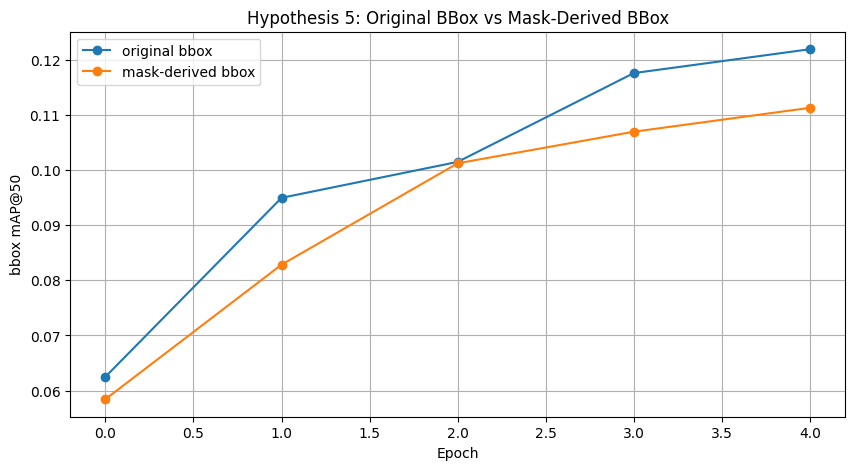

In [ ]:
plt.figure(figsize=(10, 5))

for run_name, filename in [
    ("original bbox", "hyp5_original_bbox_heads_5_eval.csv"),
    ("mask-derived bbox", "hyp5_mask_bbox_heads_5_eval.csv"),
]:
    df_eval = pd.read_csv(os.path.join(DEFAULT_RUNS_PATH, filename))
    plt.plot(
        df_eval["epoch"],
        df_eval["eval/bbox_map_50"],
        marker="o",
        label=run_name,
    )

plt.xlabel("Epoch")
plt.ylabel("bbox mAP@50")
plt.title("Hypothesis 5: Original BBox vs Mask-Derived BBox")
plt.legend()
plt.grid(True)
plt.show()

## Observations

Original bounding boxes perform consistently, but only moderately, better than mask-derived boxes:

- `bbox_map_50`: **0.122** vs **0.111**
- `bbox_map`: **0.079** vs **0.070**
- `bbox_mar_100`: **0.207** vs **0.196**
- Match rate: **0.399** vs **0.392**
- Classification accuracy on matches: **0.352** vs **0.337**

Prediction counts and unmatched confidence are nearly identical. Therefore, the improvement is
associated with slightly better localization targets rather than a major change in model confidence or
prediction volume.

## Conclusion

The hypothesis is partially supported. Original annotations provide better detection results, but the difference is too small to explain the overall low mAP. Box source is a secondary factor; category confusion and object difficulty remain larger bottlenecks.

One limitation is that each model is evaluated using its corresponding box source. For a stricter comparison of training targets, evaluate both checkpoints against the same validation targets, preferably the original annotated boxes.

# Hypothesis 6: Object size is a major reason for low detection performance

This hypothesis tests whether small object size is a major cause of low detection performance. The dataset contains images of different resolutions, so object size is measured using the bounding-box area relative to the total image area:

$$[
r = \frac{\text{bbox area}}{\text{image area}}
]
$$

Objects are divided into four relative-size groups:

- `tiny`: ($\large r < 0.001$)
- `small`: ($\large 0.001 \le r < 0.01$)
- `medium`: ($\large 0.01 \le r < 0.05$)
- `large`: ($\large r \ge 0.05$)

Predictions are matched to ground-truth boxes using `IoU >= 0.5`, independently of class labels. Match rate meaures localization performance, while classification accuracy on matched boxes measures classification after successful localization.

In [ ]:
from typing import Any


class TacoDatasetOriginalBoxesWithAnnotations(Dataset):
    """TACO dataset that preserves annotation IDs for instance diagnostics."""

    def __init__(
        self,
        df: pd.DataFrame,
        label_map: dict[object, int],
        label_col: str = "category_id",
        transform: Any | None = None,
        return_masks: bool = True,
        use_original_boxes: bool = True,
        annotation_id_col: str = "id",
    ) -> None:
        """Initialize the grouped image dataset.

        Args:
            df (pd.DataFrame): Object-level annotations with image paths,
                boxes, labels, and optional polygon segmentations.
            label_map (dict[object, int]): Mapping from dataframe labels to
                contiguous detector class IDs.
            label_col (str): Dataframe column containing target labels.
            transform (Any | None): Optional joint image-and-mask transform.
            return_masks (bool): Whether targets include instance masks.
            use_original_boxes (bool): Whether to use annotated boxes instead
                of boxes reconstructed from masks.
            annotation_id_col (str): Column containing stable annotation IDs.
        """
        # Group rows by image because each dataframe row represents one instance.
        self.image_groups = list(df.groupby("image_id"))
        self.label_map = label_map
        self.label_col = label_col
        self.transform = transform
        self.return_masks = return_masks
        self.use_original_boxes = use_original_boxes
        self.annotation_id_col = annotation_id_col

    def __getitem__(
        self,
        idx: int,
    ) -> tuple[torch.Tensor, dict[str, torch.Tensor]]:
        """Load one image and construct its detection target.

        Args:
            idx (int): Image-group position in the dataset.

        Returns:
            tuple[torch.Tensor, dict[str, torch.Tensor]]: Normalized image
                tensor and target dictionary containing boxes, labels, image
                ID, annotation IDs, area, crowd flags, and optional masks.
        """
        image_id, group = self.image_groups[idx]
        file_path = group.iloc[0]["file_path"]

        img = read_image(file_path).float() / 255.0
        _, H, W = img.shape

        boxes = []
        labels = []
        masks = []
        annotation_ids = []

        # Masks are also required when transforms or mask-derived boxes are used.
        need_masks = (
            self.return_masks
            or self.transform is not None
            or not self.use_original_boxes
        )

        for row_idx, row in group.iterrows():
            label = self.label_map[row[self.label_col]]
            labels.append(label)

            # Preserve a stable key for joining each target with dataframe metadata.
            if self.annotation_id_col in row:
                annotation_ids.append(int(row[self.annotation_id_col]))
            else:
                annotation_ids.append(int(row_idx))

            bbox = ast.literal_eval(row["bbox"]) if isinstance(row["bbox"], str) else row["bbox"]
            x, y, w, h = bbox
            boxes.append([x, y, x + w, y + h])

            if need_masks:
                segmentation = (
                    ast.literal_eval(row["segmentation"])
                    if isinstance(row["segmentation"], str)
                    else row["segmentation"]
                )

                mask = polygons_to_masks(segmentation, H, W)
                mask = mask.sum(dim=0).clamp(max=1).to(torch.uint8)
                masks.append(mask)

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)
        annotation_ids = torch.tensor(annotation_ids, dtype=torch.int64)

        # Clamp annotations to valid image coordinates before area calculations.
        boxes[:, [0, 2]] = boxes[:, [0, 2]].clamp(0, W)
        boxes[:, [1, 3]] = boxes[:, [1, 3]].clamp(0, H)

        if len(masks) > 0:
            masks = torch.stack(masks)
        else:
            masks = torch.zeros((len(labels), H, W), dtype=torch.uint8)

        if not self.use_original_boxes:
            # Use the tight rectangular extent of each binary instance mask.
            boxes = masks_to_boxes(masks)

        if self.transform is not None:
            # Transform masks jointly with the image, then recompute aligned boxes.
            image_np = (img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            masks_np = [m.numpy() for m in masks]

            transformed = self.transform(
                image=image_np,
                masks=masks_np,
            )

            image_np = transformed["image"]
            masks_np = transformed["masks"]

            img = torch.from_numpy(image_np).permute(2, 0, 1).float() / 255.0

            if len(masks_np) > 0:
                masks = torch.stack([
                    torch.from_numpy(m.astype(np.uint8))
                    for m in masks_np
                ])
            else:
                _, H, W = img.shape
                masks = torch.zeros((0, H, W), dtype=torch.uint8)

            boxes = masks_to_boxes(masks)

        # Remove degenerate boxes and empty masks created by invalid data or transforms.
        keep = (
            (boxes[:, 2] > boxes[:, 0])
            & (boxes[:, 3] > boxes[:, 1])
        )

        if need_masks:
            keep = keep & (masks.flatten(1).sum(dim=1) > 0)

        boxes = boxes[keep]
        labels = labels[keep]
        annotation_ids = annotation_ids[keep]

        if need_masks:
            masks = masks[keep]
        else:
            _, H, W = img.shape
            masks = torch.zeros((len(boxes), H, W), dtype=torch.uint8)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([image_id]),
            "annotation_ids": annotation_ids,
            "area": (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]),
            "iscrowd": torch.zeros((len(boxes),), dtype=torch.int64),
        }

        if self.return_masks:
            target["masks"] = masks

        return img, target

    def __len__(self) -> int:
        """Return the number of unique images in the dataset."""
        return len(self.image_groups)

In [ ]:
from collections import Counter

def collate_fn(
    batch: list[tuple[torch.Tensor, dict[str, torch.Tensor]]],
) -> tuple[tuple[torch.Tensor, ...], tuple[dict[str, torch.Tensor], ...]]:
    """Transpose a detection batch into image and target sequences.

    Args:
        batch (list[tuple[torch.Tensor, dict[str, torch.Tensor]]]): Samples
            produced by the detection dataset.

    Returns:
        tuple[tuple[torch.Tensor, ...], tuple[dict[str, torch.Tensor], ...]]:
            Separate image and target tuples accepted by Mask R-CNN.
    """
    return tuple(zip(*batch))

def get_loaders(
    df: pd.DataFrame,
    label_map: dict[object, int],
    label_col: str = "supercategory_reduced",
    train_transform: Any | None = None,
    return_masks: bool = True,
    use_original_boxes: bool = True,
    train_batch_size: int = 2,
    val_batch_size: int = 4,
    pin_memory: bool = False,
    num_workers: int = 2,
) -> tuple[DataLoader, DataLoader]:
    """Build train and validation loaders with annotation IDs.

    Args:
        df (pd.DataFrame): Object-level annotation dataframe.
        label_map (dict[object, int]): Mapping from labels to detector IDs.
        label_col (str): Dataframe column containing training labels.
        train_transform (Any | None): Optional training-only transform.
        return_masks (bool): Whether targets contain instance masks.
        use_original_boxes (bool): Whether targets use annotated boxes.
        train_batch_size (int): Number of training images per batch.
        val_batch_size (int): Number of validation images per batch.
        pin_memory (bool): Whether loaders use pinned host memory.
        num_workers (int): Number of worker processes per loader.

    Returns:
        tuple[DataLoader, DataLoader]: Deterministically split training and
            validation loaders.
    """
    # Use a transform-free dataset for stable split and sampler metadata.
    base_dataset = TacoDatasetOriginalBoxesWithAnnotations(
      df=df,
      label_map=label_map,
      label_col=label_col,
      transform=None,
      return_masks=return_masks,
      use_original_boxes=use_original_boxes
    )

    train_size = int(0.8 * len(base_dataset))
    val_size = len(base_dataset) - train_size

    # Keep the validation images identical to the preceding experiments.
    train_indices, val_indices = torch.utils.data.random_split(
        range(len(base_dataset)),
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42),
    )

    # Separate dataset instances prevent training transforms from leaking into validation.
    train_dataset_full = TacoDatasetOriginalBoxesWithAnnotations(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=train_transform,
        return_masks=return_masks,
        use_original_boxes=use_original_boxes
    )

    val_dataset_full = TacoDatasetOriginalBoxesWithAnnotations(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=None,
        return_masks=return_masks,
        use_original_boxes=use_original_boxes
    )
    train_dataset = Subset(train_dataset_full, train_indices.indices)
    val_dataset = Subset(val_dataset_full, val_indices.indices)
    # Estimate class frequencies exclusively from the training split.
    class_counts = Counter()

    for dataset_idx in train_dataset.indices:
        image_id, group = base_dataset.image_groups[dataset_idx]

        labels = [
            label_map[cat_id]
            for cat_id in group[label_col].tolist()
        ]

        class_counts.update(labels)

    # Inverse square-root weighting limits excessive rare-class oversampling.
    class_weights = {
        cls: 1.0 / np.sqrt(count)
        for cls, count in class_counts.items()
    }
    sample_weights = []

    # Assign each image the largest weight among the classes it contains.
    for dataset_idx in train_dataset.indices:
        image_id, group = base_dataset.image_groups[dataset_idx]

        labels = [
            label_map[cat_id]
            for cat_id in group[label_col].tolist()
        ]

        weight = max(class_weights[label] for label in labels)
        sample_weights.append(weight)

    sample_weights = torch.DoubleTensor(sample_weights)

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=train_batch_size,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=False,
        sampler=sampler,
        collate_fn=collate_fn
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=val_batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=False,
        collate_fn=collate_fn
    )
    return train_loader, val_loader


In [ ]:
top_supercats = df["supercategory"].value_counts().head(10).index.tolist()
df_supercats = df.copy()
df_supercats["supercategory_reduced"] = df_supercats["supercategory"].where(
    df_supercats["supercategory"].isin(top_supercats),
    "Other",
)

label_values = sorted(df_supercats["supercategory_reduced"].unique())
label_map = {name: i + 1 for i, name in enumerate(label_values)}
num_classes = len(label_map) + 1

train_loader, val_loader = get_loaders(
    df=df_supercats,
    label_map=label_map,
    label_col="supercategory_reduced",
    train_transform=None,
    num_workers=2,
)

In [ ]:
import ast
import numpy as np
import pandas as pd
import torch
from torchvision.ops import box_iou
from tqdm import tqdm

def parse_bbox(
    bbox: str | list[float] | tuple[float, float, float, float],
) -> list[float] | tuple[float, float, float, float]:
    """Convert a serialized bounding box into numeric coordinates.

    Args:
        bbox (str | list[float] | tuple[float, float, float, float]): Box in
            COCO ``[x, y, width, height]`` format.

    Returns:
        list[float] | tuple[float, float, float, float]: Parsed box values.
    """
    if isinstance(bbox, str):
        bbox = ast.literal_eval(bbox)
    return bbox


def bbox_size_bucket(area_ratio: float) -> str:
    """Assign an object to a relative-area size bucket.

    Args:
        area_ratio (float): Bounding-box area divided by image area.

    Returns:
        str: One of ``tiny``, ``small``, ``medium``, or ``large``.
    """
    # Relative thresholds remain meaningful across different image resolutions.
    if area_ratio < 0.001:
        return "tiny"
    if area_ratio < 0.01:
        return "small"
    if area_ratio < 0.05:
        return "medium"
    return "large"


def add_bbox_size_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Add bounding-box geometry and relative-size metadata.

    Args:
        df (pd.DataFrame): Annotation dataframe with ``bbox``, ``width``,
            and ``height`` columns.

    Returns:
        pd.DataFrame: Copy of the annotations with box coordinates, absolute
            area, image area, relative area, and size bucket columns.
    """
    # Preserve the original index because it is used as the annotation lookup key.
    df_size = df.copy()

    bbox_values = df_size["bbox"].apply(parse_bbox)

    df_size["bbox_x"] = bbox_values.apply(lambda b: b[0])
    df_size["bbox_y"] = bbox_values.apply(lambda b: b[1])
    df_size["bbox_w"] = bbox_values.apply(lambda b: b[2])
    df_size["bbox_h"] = bbox_values.apply(lambda b: b[3])

    # Normalize object area by image area to compare different resolutions.
    df_size["bbox_area"] = df_size["bbox_w"] * df_size["bbox_h"]
    df_size["image_area"] = df_size["width"] * df_size["height"]
    df_size["bbox_area_ratio"] = df_size["bbox_area"] / df_size["image_area"]

    df_size["bbox_size_bucket"] = df_size["bbox_area_ratio"].apply(bbox_size_bucket)

    return df_size

df_size = add_bbox_size_columns(df_supercats)

df_size[[
    "bbox_w",
    "bbox_h",
    "bbox_area",
    "bbox_area_ratio",
]].describe()

df_size["bbox_size_bucket"].value_counts()

df_size["bbox_size_bucket"].value_counts(normalize=True)


# if "supercategory_reduced" in df_size.columns:
#     size_by_class = pd.crosstab(
#         df_size["supercategory_reduced"],
#         df_size["bbox_size_bucket"],
#         normalize="index",
#     )

#     display(size_by_class)

bbox_size_bucket
tiny      0.337584
small     0.334448
medium    0.202341
large     0.125627
Name: proportion, dtype: float64

In [ ]:
@torch.no_grad()
def collect_detection_by_size(
    model: torch.nn.Module,
    dataloader: DataLoader,
    df_size: pd.DataFrame,
    device: torch.device,
    score_threshold: float = 0.05,
    iou_threshold: float = 0.5,
    detections_per_img: int = 100,
) -> pd.DataFrame:
    """Collect per-instance detection outcomes grouped by object size.

    Predicted and ground-truth boxes are matched greedily by descending IoU.
    Matching ignores class labels so localization and classification can be
    measured separately.

    Args:
        model (torch.nn.Module): Trained torchvision detection model.
        dataloader (DataLoader): Validation loader whose targets contain
            ``annotation_ids``.
        df_size (pd.DataFrame): Annotation metadata indexed by annotation ID
            and containing the size columns created earlier.
        device (torch.device): Device used for model inference.
        score_threshold (float): Minimum prediction confidence retained for
            matching.
        iou_threshold (float): Minimum IoU required to match a prediction to
            a ground-truth box.
        detections_per_img (int): Maximum predictions retained per image.

    Returns:
        pd.DataFrame: One row per ground-truth instance with object-size,
            localization, classification, and confidence diagnostics.
    """
    model.eval()

    rows = []

    # Save inference settings because this diagnostic temporarily overrides them.
    previous_score_thresh = model.roi_heads.score_thresh
    previous_detections_per_img = model.roi_heads.detections_per_img

    model.roi_heads.score_thresh = score_threshold
    model.roi_heads.detections_per_img = detections_per_img

    try:
        loader = tqdm(dataloader, total=len(dataloader), desc="Collect size diagnostics")

        for images, targets in loader:
            images = [img.to(device) for img in images]

            with torch.amp.autocast("cuda", enabled=device.type == "cuda"):
                outputs = model(images)

            for out, target in zip(outputs, targets):
                pred_boxes = out["boxes"].detach().cpu()
                pred_scores = out["scores"].detach().cpu()
                pred_labels = out["labels"].detach().cpu()

                # Apply the same confidence threshold before matching every image.
                keep = pred_scores >= score_threshold

                pred_boxes = pred_boxes[keep]
                pred_scores = pred_scores[keep]
                pred_labels = pred_labels[keep]

                gt_boxes = target["boxes"].detach().cpu()
                gt_labels = target["labels"].detach().cpu()
                annotation_ids = target["annotation_ids"].detach().cpu()

                matched_gt = set()
                matched_pred_for_gt = {}

                if len(pred_boxes) > 0 and len(gt_boxes) > 0:
                    # Match geometry without labels to diagnose classification separately.
                    ious = box_iou(pred_boxes, gt_boxes)

                    used_pred = set()
                    used_gt = set()

                    # Greedily enforce one-to-one matches from highest to lowest IoU.
                    while ious.numel() > 0:
                        max_iou = ious.max().item()

                        if max_iou < iou_threshold:
                            break

                        flat_idx = ious.argmax().item()
                        pred_idx = flat_idx // ious.shape[1]
                        gt_idx = flat_idx % ious.shape[1]

                        if pred_idx in used_pred or gt_idx in used_gt:
                            ious[pred_idx, gt_idx] = -1
                            continue

                        used_pred.add(pred_idx)
                        used_gt.add(gt_idx)

                        matched_gt.add(gt_idx)
                        matched_pred_for_gt[gt_idx] = pred_idx

                        ious[pred_idx, :] = -1
                        ious[:, gt_idx] = -1

                for gt_idx in range(len(gt_boxes)):
                    annotation_id = int(annotation_ids[gt_idx])
                    # Join the target back to its precomputed relative-size metadata.
                    meta = df_size.loc[annotation_id]

                    is_matched = gt_idx in matched_gt

                    pred_label = None
                    pred_score = None
                    class_correct = False

                    if is_matched:
                        pred_idx = matched_pred_for_gt[gt_idx]
                        pred_label = int(pred_labels[pred_idx])
                        pred_score = float(pred_scores[pred_idx])
                        class_correct = pred_label == int(gt_labels[gt_idx])

                    rows.append({
                        "annotation_id": annotation_id,
                        "image_id": int(target["image_id"].item()),
                        "size_bucket": meta["bbox_size_bucket"],
                        "bbox_area_ratio": float(meta["bbox_area_ratio"]),
                        "bbox_w": float(meta["bbox_w"]),
                        "bbox_h": float(meta["bbox_h"]),
                        "bbox_area": float(meta["bbox_area"]),
                        "gt_label": int(gt_labels[gt_idx]),
                        "matched": bool(is_matched),
                        "class_correct": bool(class_correct),
                        "pred_label": pred_label,
                        "pred_score": pred_score,
                    })

            del images, outputs

    finally:
        # Restore model configuration even if evaluation raises an exception.
        model.roi_heads.score_thresh = previous_score_thresh
        model.roi_heads.detections_per_img = previous_detections_per_img

    return pd.DataFrame(rows)

In [ ]:
# https://drive.google.com/file/d/1wVHFzY4wrPrc33FYry9AVIz8TyrHAv52/view?usp=sharing
!gdown 1wVHFzY4wrPrc33FYry9AVIz8TyrHAv52

Downloading...
From (original): https://drive.google.com/uc?id=1wVHFzY4wrPrc33FYry9AVIz8TyrHAv52
From (redirected): https://drive.google.com/uc?id=1wVHFzY4wrPrc33FYry9AVIz8TyrHAv52&confirm=t&uuid=27dfef7b-0ac6-4646-84bd-d8364a4f0415
To: /home/ubuntu/full_40_bbox_scheduler_max_top_10_categories_best_model.pt
100%|███████████████████████████████████████| 352M/352M [00:04<00:00, 78.7MB/s]


In [ ]:
model = get_model(num_classes=num_classes, train_mode="all")
_ = load_checkpoint(
  path=os.path.join(ROOT_PATH,"full_40_bbox_scheduler_max_top_10_categories_best_model.pt"),
  model=model,
  device=device,
)

size_eval_df = collect_detection_by_size(
    model=model,
    dataloader=val_loader,
    df_size=df_size,
    device=device,
    score_threshold=0.05,
    iou_threshold=0.5,
    detections_per_img=100,
)

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /home/ubuntu/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 455MB/s] 
Collect size diagnostics: 100%|██████████| 75/75 [01:15<00:00,  1.01s/it]


In [ ]:
size_summary = (
      size_eval_df
      .groupby("size_bucket")
      .agg(
          gt_count=("annotation_id", "count"),
          matched_count=("matched", "sum"),
          class_correct_count=("class_correct", "sum"),
          mean_area_ratio=("bbox_area_ratio", "mean"),
          median_area_ratio=("bbox_area_ratio", "median"),
      )
      .reset_index()
  )

In [ ]:
size_summary["match_rate"] = (
    size_summary["matched_count"] / size_summary["gt_count"]
)

size_summary["class_accuracy_on_matches"] = (
    size_summary["class_correct_count"]
    / size_summary["matched_count"].replace(0, np.nan)
)

bucket_order = ["tiny", "small", "medium", "large"]
size_summary["size_bucket"] = pd.Categorical(
    size_summary["size_bucket"],
    categories=bucket_order,
    ordered=True,
)

size_summary = size_summary.sort_values("size_bucket")

size_summary

,size_bucket,gt_count,matched_count,class_correct_count,mean_area_ratio,median_area_ratio,match_rate,class_accuracy_on_matches
3,tiny,258,70,38,0.000380,0.000313,0.271318,0.542857
2,small,255,111,32,0.004324,0.003828,0.435294,0.288288
1,medium,187,97,47,0.022443,0.019829,0.518717,0.484536
0,large,96,73,37,0.181131,0.116390,0.760417,0.506849


In [ ]:
id_to_name = {
    model_id: class_name
    for class_name, model_id in label_map.items()
}

In [ ]:
size_eval_df["gt_class_name"] = size_eval_df["gt_label"].map(id_to_name)

if "pred_label" in size_eval_df.columns:
    size_eval_df["pred_class_name"] = size_eval_df["pred_label"].map(id_to_name)

In [ ]:
class_size_summary = (
    size_eval_df
    .groupby(["gt_class_name", "size_bucket"])
    .agg(
        gt_count=("annotation_id", "count"),
        matched_count=("matched", "sum"),
        class_correct_count=("class_correct", "sum"),
    )
    .reset_index()
)

class_size_summary["match_rate"] = (
    class_size_summary["matched_count"] / class_size_summary["gt_count"]
)

class_size_summary["class_accuracy_on_matches"] = (
    class_size_summary["class_correct_count"]
    / class_size_summary["matched_count"].replace(0, np.nan)
)

class_size_summary.sort_values(["size_bucket", "match_rate"])

,gt_class_name,size_bucket,gt_count,matched_count,class_correct_count,match_rate,class_accuracy_on_matches
4,Bottle cap,large,3,1,1,0.333333,1.000000
34,Straw,large,4,2,1,0.500000,0.500000
22,Other,large,23,17,9,0.739130,0.529412
18,Cup,large,4,3,0,0.750000,0.000000
30,Plastic bag & wrapper,large,20,15,7,0.750000,0.466667
0,Bottle,large,20,16,9,0.800000,0.562500
12,Carton,large,11,9,5,0.818182,0.555556
8,Can,large,8,7,5,0.875000,0.714286
26,Other plastic,large,3,3,0,1.000000,0.000000
38,Unlabeled litter,medium,9,0,0,0.000000,NaN


In [ ]:
size_eval_df.to_csv(os.path.join(ROOT_PATH, "hyp6_object_size_eval_details.csv"), index=False)
size_summary.to_csv(os.path.join(ROOT_PATH, "hyp6_object_size_eval_summary.csv"), index=False)
class_size_summary.to_csv(os.path.join(ROOT_PATH, "hyp6_object_size_class_summary.csv"), index=False)

In [ ]:
!rclone copy ./taco_trash gdrive:taco_trash --progress
!rclone copy checkpoints gdrive:taco_trash/checkpoints --progress


2026/06/17 08:47:03 ERROR : Local file system at /home/ubuntu/taco_trash: error reading source root directory: directory not found
Transferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 60
Elapsed time:         0.2s
2026/06/17 08:47:03 ERROR : Attempt 1/3 failed with 1 errors and: directory not found
Transferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Errors:                 1 (retrying may help)
Checks:                 0 / 0, -, Listed 60
Elapsed time:         0.2sTransferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 60
Elapsed time:         0.5s
2026/06/17 08:47:03 ERROR : Local file system at /home/ubuntu/taco_trash: error reading source root directory: directory not found
Transferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 120
Elapsed time:         0.5s
2026/06/17 08:47:03 ERROR : Attempt 2/3 failed with 1 errors and: directory not found
Transferred:   	       

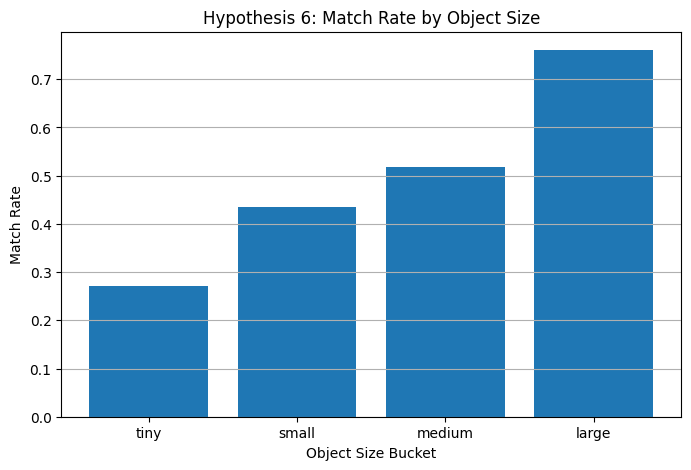

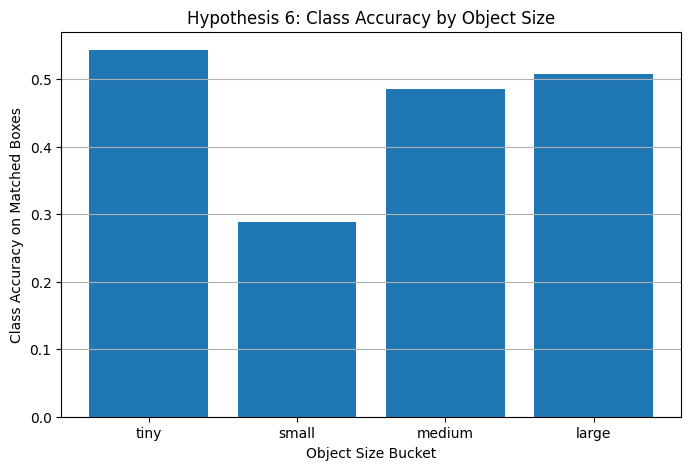

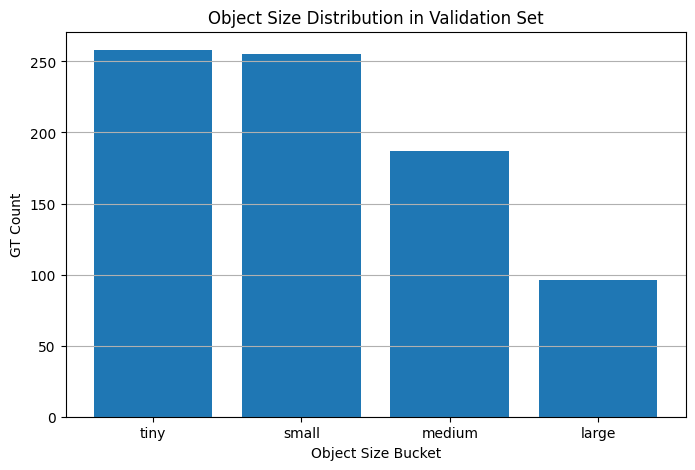

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(size_summary["size_bucket"], size_summary["match_rate"])
plt.xlabel("Object Size Bucket")
plt.ylabel("Match Rate")
plt.title("Hypothesis 6: Match Rate by Object Size")
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(size_summary["size_bucket"], size_summary["class_accuracy_on_matches"])
plt.xlabel("Object Size Bucket")
plt.ylabel("Class Accuracy on Matched Boxes")
plt.title("Hypothesis 6: Class Accuracy by Object Size")
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(size_summary["size_bucket"], size_summary["gt_count"])
plt.xlabel("Object Size Bucket")
plt.ylabel("GT Count")
plt.title("Object Size Distribution in Validation Set")
plt.grid(axis="y")
plt.show()

In [ ]:
size_summary[[
    "size_bucket",
    "gt_count",
    "matched_count",
    "match_rate",
    "class_accuracy_on_matches",
]]

,size_bucket,gt_count,matched_count,match_rate,class_accuracy_on_matches
3,tiny,258,70,0.271318,0.542857
2,small,255,111,0.435294,0.288288
1,medium,187,97,0.518717,0.484536
0,large,96,73,0.760417,0.506849


# Hypothesis 7: “Other” Class Is Too Broad

This hypothesis tests whether the `Other` class is too heterogeneous to learn reliably. It combines multiple uncommon categories with different visual characteristics into one label. Consequently, the model may learn an unclear decision boundary between `Other` and the explicitly named classes.

Predictions are matched to ground-truth boxes using IoU >= 0.5 without considering class labels. Matched instances are then divided into:

- Correct classifications.
- Other ground truth predicted as a named class.
- Named-class ground truth predicted as `Other`.
- Confusion between two named classes.
- Ground-truth objects without a matched prediction.

This separates localization failures from classification errors involving the catch-all category.

In [ ]:
top_supercats = df["supercategory"].value_counts().head(10).index.tolist()
df_supercats = df.copy()
df_supercats["supercategory_reduced"] = df_supercats["supercategory"].where(
    df_supercats["supercategory"].isin(top_supercats),
    "Other",
)

label_values = sorted(df_supercats["supercategory_reduced"].unique())
label_map = {name: i + 1 for i, name in enumerate(label_values)}
id_to_name = {
    class_id: name
    for name, class_id in label_map.items()
}
num_classes = len(label_map) + 1

train_loader, val_loader = get_loaders(
    df=df_supercats,
    label_map=label_map,
    label_col="supercategory_reduced",
    train_batch_size=4,
    train_transform=None,
    num_workers=6,
)

model = get_model(num_classes=num_classes, train_mode="all")
_ = load_checkpoint(
  path=os.path.join(DEFAULT_RUNS_PATH, "checkpoints", "full_40_bbox_scheduler_max_top_10_categories_best_model.pt"),
  model=model,
  device=device,
)

In [ ]:
import os
import pandas as pd
import torch
from torchvision.ops import box_iou
from tqdm import tqdm

def get_other_class_id(
    label_map: dict[str, int],
    other_name: str = "Other",
) -> int:
    """Return the detector class ID assigned to the catch-all class.

    Args:
        label_map (dict[str, int]): Mapping from class names to detector IDs.
        other_name (str): Name of the catch-all class.

    Returns:
        int: Detector class ID corresponding to ``other_name``.

    Raises:
        ValueError: If the catch-all class is absent from ``label_map``.
    """
    if other_name not in label_map:
        raise ValueError(f"{other_name!r} is not in label_map")

    return label_map[other_name]

@torch.no_grad()
def collect_other_class_diagnostics(
    model: torch.nn.Module,
    dataloader: DataLoader,
    device: torch.device,
    label_map: dict[str, int],
    id_to_name: dict[int, str],
    score_threshold: float = 0.05,
    iou_threshold: float = 0.5,
    detections_per_img: int = 50,
    other_name: str = "Other",
) -> pd.DataFrame:
    """Collect localization and classification errors involving ``Other``.

    Predictions are greedily matched to ground-truth boxes by IoU without
    considering labels. This separates localization failures from confusion
    between named classes and the catch-all class.

    Args:
        model (torch.nn.Module): Trained torchvision detection model.
        dataloader (DataLoader): Validation loader providing detection targets.
        device (torch.device): Device used for model inference.
        label_map (dict[str, int]): Mapping from class names to detector IDs.
        id_to_name (dict[int, str]): Reverse mapping from IDs to class names.
        score_threshold (float): Minimum prediction confidence retained.
        iou_threshold (float): Minimum IoU required for a geometric match.
        detections_per_img (int): Maximum predictions retained per image.
        other_name (str): Name of the catch-all class under investigation.

    Returns:
        pd.DataFrame: One row per ground-truth instance with matching status,
            predicted class, confidence, IoU, and categorized error type.
    """
    model.eval()

    # Preserve inference settings because the diagnostic uses permissive thresholds.
    previous_score_thresh = model.roi_heads.score_thresh
    previous_detections_per_img = model.roi_heads.detections_per_img

    model.roi_heads.score_thresh = score_threshold
    model.roi_heads.detections_per_img = detections_per_img

    other_id = get_other_class_id(label_map, other_name=other_name)

    rows = []

    try:
        for images, targets in tqdm(dataloader, total=len(dataloader), desc="Other diagnostics"):
            images = [img.to(device) for img in images]

            outputs = model(images)

            for image_idx, (out, target) in enumerate(zip(outputs, targets)):
                pred_boxes = out["boxes"].detach().cpu()
                pred_labels = out["labels"].detach().cpu()
                pred_scores = out["scores"].detach().cpu()

                # Remove predictions below the common diagnostic threshold.
                keep_pred = pred_scores >= score_threshold

                pred_boxes = pred_boxes[keep_pred]
                pred_labels = pred_labels[keep_pred]
                pred_scores = pred_scores[keep_pred]

                gt_boxes = target["boxes"].detach().cpu()
                gt_labels = target["labels"].detach().cpu()

                image_id = (
                    int(target["image_id"].item())
                    if "image_id" in target
                    else None
                )

                # Stable annotation IDs are preferred; positions are a fallback.
                if "annotation_ids" in target:
                    annotation_ids = target["annotation_ids"].detach().cpu().tolist()
                else:
                    annotation_ids = list(range(len(gt_boxes)))

                if len(gt_boxes) == 0:
                    continue

                if len(pred_boxes) == 0:
                    # Record every ground-truth object as missed when no boxes survive.
                    for gt_idx in range(len(gt_boxes)):
                        gt_label = int(gt_labels[gt_idx])

                        rows.append({
                            "image_id": image_id,
                            "annotation_id": int(annotation_ids[gt_idx]),
                            "gt_label": gt_label,
                            "gt_name": id_to_name.get(gt_label, str(gt_label)),
                            "pred_label": None,
                            "pred_name": None,
                            "pred_score": None,
                            "iou": 0.0,
                            "matched": False,
                            "class_correct": False,
                            "gt_is_other": gt_label == other_id,
                            "pred_is_other": False,
                            "error_type": "missed_gt",
                        })

                    continue

                # Match by geometry first so class errors can be analyzed independently.
                ious = box_iou(pred_boxes, gt_boxes)

                matched_pred = set()
                matched_gt = set()

                # Greedily enforce one-to-one matches from highest to lowest IoU.
                while ious.numel() > 0:
                    max_iou = ious.max().item()
                    if max_iou < iou_threshold:
                        break

                    flat_idx = ious.argmax().item()
                    pred_idx = flat_idx // ious.shape[1]
                    gt_idx = flat_idx % ious.shape[1]

                    if pred_idx in matched_pred or gt_idx in matched_gt:
                        ious[pred_idx, gt_idx] = -1
                        continue

                    matched_pred.add(pred_idx)
                    matched_gt.add(gt_idx)

                    gt_label = int(gt_labels[gt_idx])
                    pred_label = int(pred_labels[pred_idx])
                    class_correct = gt_label == pred_label

                    # Distinguish errors entering/leaving Other from named-class confusion.
                    if class_correct:
                        error_type = "correct"
                    elif gt_label == other_id and pred_label != other_id:
                        error_type = "other_gt_pred_top_class"
                    elif gt_label != other_id and pred_label == other_id:
                        error_type = "top_class_gt_pred_other"
                    else:
                        error_type = "top_class_confusion"

                    rows.append({
                        "image_id": image_id,
                        "annotation_id": int(annotation_ids[gt_idx]),
                        "gt_label": gt_label,
                        "gt_name": id_to_name.get(gt_label, str(gt_label)),
                        "pred_label": pred_label,
                        "pred_name": id_to_name.get(pred_label, str(pred_label)),
                        "pred_score": float(pred_scores[pred_idx]),
                        "iou": float(max_iou),
                        "matched": True,
                        "class_correct": class_correct,
                        "gt_is_other": gt_label == other_id,
                        "pred_is_other": pred_label == other_id,
                        "error_type": error_type,
                    })

                    ious[pred_idx, :] = -1
                    ious[:, gt_idx] = -1

                # Add unmatched ground-truth instances omitted by the greedy matching loop.
                for gt_idx in range(len(gt_boxes)):
                    if gt_idx in matched_gt:
                        continue

                    gt_label = int(gt_labels[gt_idx])

                    rows.append({
                        "image_id": image_id,
                        "annotation_id": int(annotation_ids[gt_idx]),
                        "gt_label": gt_label,
                        "gt_name": id_to_name.get(gt_label, str(gt_label)),
                        "pred_label": None,
                        "pred_name": None,
                        "pred_score": None,
                        "iou": 0.0,
                        "matched": False,
                        "class_correct": False,
                        "gt_is_other": gt_label == other_id,
                        "pred_is_other": False,
                        "error_type": "missed_gt",
                    })

    finally:
        # Restore the model even if diagnostic collection raises an exception.
        model.roi_heads.score_thresh = previous_score_thresh
        model.roi_heads.detections_per_img = previous_detections_per_img

    return pd.DataFrame(rows)

In [ ]:
other_diagnostics_df = collect_other_class_diagnostics(
    model=model,
    dataloader=val_loader,
    device=device,
    label_map=label_map,
    id_to_name=id_to_name,
    score_threshold=0.05,
    iou_threshold=0.5,
    detections_per_img=50,
    other_name="Other",
)

Other diagnostics: 100%|██████████| 75/75 [00:52<00:00,  1.44it/s]


In [ ]:
other_diagnostics_df.head()

,image_id,annotation_id,gt_label,gt_name,pred_label,pred_name,pred_score,iou,matched,class_correct,gt_is_other,pred_is_other,error_type
0,507,0,1,Bottle,4.0,Carton,0.782444,0.870633,True,False,False,False,top_class_confusion
1,507,1,2,Bottle cap,2.0,Bottle cap,0.279208,0.657083,True,True,False,False,correct
2,149,0,11,Unlabeled litter,11.0,Unlabeled litter,0.872703,0.856066,True,True,False,False,correct
3,149,1,7,Other,3.0,Can,0.057723,0.734348,True,False,True,False,other_gt_pred_top_class
4,149,3,9,Plastic bag & wrapper,9.0,Plastic bag & wrapper,0.234473,0.568852,True,True,False,False,correct


In [ ]:
def summarize_other_class_diagnostics(
    df_diag: pd.DataFrame,
    other_name: str = "Other",
) -> pd.DataFrame:
    """Compare aggregate diagnostics for ``Other`` and named classes.

    Args:
        df_diag (pd.DataFrame): Per-instance output produced by
            ``collect_other_class_diagnostics``.
        other_name (str): Name of the catch-all class.

    Returns:
        pd.DataFrame: One-row summary containing localization rates,
            classification accuracy, and cross-boundary confusion counts.
    """
    # Establish overall baselines before splitting instances by class type.
    total_gt = len(df_diag)
    matched = df_diag["matched"].sum()
    correct = df_diag["class_correct"].sum()

    summary = {
        "total_gt": total_gt,
        "matched_gt": matched,
        "overall_match_rate": matched / max(total_gt, 1),
        "overall_class_accuracy_on_matches": correct / max(matched, 1),
    }

    # Compare the heterogeneous catch-all class against all named classes combined.
    other_df = df_diag[df_diag["gt_name"] == other_name]
    non_other_df = df_diag[df_diag["gt_name"] != other_name]

    other_matched = other_df["matched"].sum()
    non_other_matched = non_other_df["matched"].sum()

    # Count directional errors to reveal whether Other attracts named predictions.
    summary.update({
        "other_gt_count": len(other_df),
        "other_match_rate": other_matched / max(len(other_df), 1),
        "other_class_accuracy_on_matches": other_df["class_correct"].sum() / max(other_matched, 1),

        "non_other_gt_count": len(non_other_df),
        "non_other_match_rate": non_other_matched / max(len(non_other_df), 1),
        "non_other_class_accuracy_on_matches": non_other_df["class_correct"].sum() /
        max(non_other_matched, 1),

        "top_class_gt_pred_other_count": (df_diag["error_type"] == "top_class_gt_pred_other").sum(),
        "other_gt_pred_top_class_count": (df_diag["error_type"] == "other_gt_pred_top_class").sum(),
    })

    return pd.DataFrame([summary])

other_summary_df = summarize_other_class_diagnostics(other_diagnostics_df)
other_summary_df

,total_gt,matched_gt,overall_match_rate,overall_class_accuracy_on_matches,other_gt_count,other_match_rate,other_class_accuracy_on_matches,non_other_gt_count,non_other_match_rate,non_other_class_accuracy_on_matches,top_class_gt_pred_other_count,other_gt_pred_top_class_count
0,796,350,0.439698,0.411429,153,0.366013,0.446429,643,0.457232,0.404762,48,31


In [ ]:
other_error_counts = (
    other_diagnostics_df["error_type"]
    .value_counts()
    .reset_index()
)

other_error_counts.columns = ["error_type", "count"]
other_error_counts

# Cases where GT is Other but model predicts a top class
other_as_top_confusions = (
    other_diagnostics_df[
        other_diagnostics_df["error_type"] == "other_gt_pred_top_class"
    ]
    .groupby(["gt_name", "pred_name"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

other_as_top_confusions.head(20)

,gt_name,pred_name,count
7,Other,Plastic bag & wrapper,8
6,Other,Other plastic,5
5,Other,Cup,4
3,Other,Carton,4
2,Other,Can,4
1,Other,Bottle cap,2
0,Other,Bottle,1
4,Other,Cigarette,1
8,Other,Straw,1
9,Other,Unlabeled litter,1


In [ ]:
# Cases where GT is a top class but model predicts Other
top_as_other_confusions = (
    other_diagnostics_df[
        other_diagnostics_df["error_type"] == "top_class_gt_pred_other"
    ]
    .groupby(["gt_name", "pred_name"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

top_as_other_confusions.head(20)

,gt_name,pred_name,count
7,Plastic bag & wrapper,Other,16
6,Other plastic,Other,10
3,Carton,Other,6
8,Unlabeled litter,Other,5
5,Cup,Other,4
0,Bottle,Other,2
2,Can,Other,2
4,Cigarette,Other,2
1,Bottle cap,Other,1


In [ ]:
per_class_other_diag = (
    other_diagnostics_df
    .groupby("gt_name")
    .agg(
        gt_count=("gt_name", "count"),
        matched_count=("matched", "sum"),
        correct_count=("class_correct", "sum"),
        mean_iou=("iou", "mean"),
        mean_pred_score=("pred_score", "mean"),
    )
    .reset_index()
)

per_class_other_diag["match_rate"] = (
    per_class_other_diag["matched_count"] / per_class_other_diag["gt_count"]
)

per_class_other_diag["class_accuracy_on_matches"] = (
    per_class_other_diag["correct_count"]
    / per_class_other_diag["matched_count"].replace(0, pd.NA)
)

per_class_other_diag.sort_values("class_accuracy_on_matches")

,gt_name,gt_count,matched_count,correct_count,mean_iou,mean_pred_score,match_rate,class_accuracy_on_matches
7,Other plastic,54,24,1,0.347267,0.241663,0.444444,0.041667
5,Cup,42,21,4,0.423380,0.291188,0.500000,0.190476
8,Plastic bag & wrapper,125,73,21,0.480929,0.322131,0.584000,0.287671
10,Unlabeled litter,73,20,6,0.208463,0.213266,0.273973,0.300000
3,Carton,39,24,10,0.507777,0.464610,0.615385,0.416667
6,Other,153,56,25,0.301395,0.342796,0.366013,0.446429
4,Cigarette,88,19,9,0.167416,0.279369,0.215909,0.473684
0,Bottle,86,55,28,0.544074,0.494124,0.639535,0.509091
2,Can,58,30,17,0.428471,0.582404,0.517241,0.566667
1,Bottle cap,56,20,16,0.286304,0.604817,0.357143,0.800000


In [ ]:
output_dir = os.path.join(DEFAULT_RUNS_PATH, "hypothesis_7_other_class")
os.makedirs(output_dir, exist_ok=True)

other_diagnostics_df.to_csv(
    os.path.join(output_dir, "other_diagnostics.csv"),
    index=False,
)

other_summary_df.to_csv(
    os.path.join(output_dir, "other_summary.csv"),
    index=False,
)

other_as_top_confusions.to_csv(
    os.path.join(output_dir, "other_as_top_confusions.csv"),
    index=False,
)

top_as_other_confusions.to_csv(
    os.path.join(output_dir, "top_as_other_confusions.csv"),
    index=False,
)

per_class_other_diag.to_csv(
    os.path.join(output_dir, "per_class_other_diagnostics.csv"),
    index=False,
)

In [ ]:
pd.DataFrame({'supercategory': df['supercategory'].unique().tolist()}).to_csv(os.path.join(DEFAULT_RUNS_PATH, "supercategory.csv"))

In [ ]:
def add_merged_supercategory(df: pd.DataFrame) -> pd.DataFrame:
    """Map original supercategories into broader semantic groups.

    Args:
        df (pd.DataFrame): Annotation dataframe containing a
            ``supercategory`` column.

    Returns:
        pd.DataFrame: Copy of the annotations with a
            ``merged_supercategory`` column.

    Raises:
        ValueError: If any source supercategory has no explicit mapping.
    """
    # Preserve source labels for comparison with the original taxonomy.
    df_merged = df.copy()

    merge_map = {
        # Containers / rigid packaging
        "Bottle": "container",
        "Bottle cap": "container",
        "Can": "container",
        "Cup": "container",
        "Plastic container": "container",
        "Glass jar": "container",
        "Lid": "container",
        "Blister pack": "container",
        "Squeezable tube": "container",

        # Flexible / generic plastic
        "Plastic bag & wrapper": "plastic_film_wrapper",
        "Other plastic": "plastic_film_wrapper",
        "Plastic utensils": "plastic_film_wrapper",
        "Plastic glooves": "plastic_film_wrapper",
        "Styrofoam piece": "plastic_film_wrapper",

        # Paper / carton
        "Carton": "paper_carton",
        "Paper": "paper_carton",
        "Paper bag": "paper_carton",

        # Metal
        "Pop tab": "metal",
        "Aluminium foil": "metal",
        "Scrap metal": "metal",

        # Glass
        "Broken glass": "glass",

        # Small thin litter
        "Straw": "small_litter",
        "Cigarette": "small_litter",
        "Rope & strings": "small_litter",

        # Organic / miscellaneous
        "Food waste": "organic_waste",

        # Hard-to-classify / rare
        "Shoe": "other_rare",
        "Battery": "other_rare",
        "Unlabeled litter": "other_rare",
    }

    # Use an explicit mapping so no category is silently absorbed into Other.
    df_merged["merged_supercategory"] = df_merged["supercategory"].map(merge_map)

    # Fail fast when the dataset contains a category not covered by the taxonomy.
    missing = df_merged[df_merged["merged_supercategory"].isna()]["supercategory"].unique()
    if len(missing) > 0:
        raise ValueError(f"Missing merge mapping for: {missing}")

    return df_merged

In [ ]:
df_merged = add_merged_supercategory(df)

top_merged_labels = (
    df_merged["merged_supercategory"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)

df_merged["merged_supercategory_reduced"] = df_merged["merged_supercategory"].where(
    df_merged["merged_supercategory"].isin(top_merged_labels),
    "Other",
)

label_values = sorted(df_merged["merged_supercategory_reduced"].unique())

label_map = {
    name: i + 1
    for i, name in enumerate(label_values)
}

id_to_name = {
    i: name
    for name, i in label_map.items()
}

num_classes = len(label_map) + 1

print(df_merged["merged_supercategory_reduced"].value_counts())
print("label_map:", label_map)
print("num_classes:", num_classes)

merged_supercategory_reduced
container               1372
plastic_film_wrapper    1276
small_litter             857
other_rare               526
paper_carton             426
metal                    181
glass                    138
organic_waste              8
Name: count, dtype: int64
label_map: {'container': 1, 'glass': 2, 'metal': 3, 'organic_waste': 4, 'other_rare': 5, 'paper_carton': 6, 'plastic_film_wrapper': 7, 'small_litter': 8}
num_classes: 9


In [ ]:
train_loader, val_loader = get_loaders(
  df=df_merged,
  label_map=label_map,
  label_col="merged_supercategory_reduced",
  train_transform=None,
  return_masks=True,
  use_original_boxes=True,
  train_batch_size=4,
  num_workers=5,
)

In [ ]:
num_epochs = 5
run_prefix = "hyp_merged_supercategories_heads_5"

In [ ]:
model = get_model(
    num_classes=num_classes,
    train_mode="heads",
)

optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-3,
    momentum=0.9,
    weight_decay=0.0005,
)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    threshold=1e-4,
    min_lr=1e-5,
)

scaler = torch.amp.GradScaler("cuda")

In [ ]:
writer = SummaryWriter(
    log_dir=os.path.join(
        DEFAULT_RUNS_PATH,
        f"runs/{run_prefix}",
    )
)

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=lr_scheduler,
    scaler=scaler,
    writer=writer,
    num_epoch=num_epochs,
    run_prefix=run_prefix,
    device=device,
    checkpoint_dir=os.path.join(DEFAULT_RUNS_PATH, "checkpoints"),
    eval_every=1,
    metrics_csv_paths={
        "train": os.path.join(
            DEFAULT_RUNS_PATH,
            f"{run_prefix}_train.csv",
        ),
        "eval": os.path.join(
            DEFAULT_RUNS_PATH,
            f"{run_prefix}_eval.csv",
        ),
    },
    scheduler_step_fn=step_on_val_bbox_map_50,
    checkpoint_score_fn=score_by_eval_bbox_map_50,
    id_to_name=id_to_name,
)

Epoch 1. Train: 100%|██████████| 300/300 [05:23<00:00,  1.08s/it]
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)
Train model. Epoch 5: 100%|██████████| 5/5 [1:30:33<00:00, 1086.67s/it]


In [ ]:
eval_df = pd.read_csv(
    os.path.join(
        DEFAULT_RUNS_PATH,
        "experiments",
        f"{run_prefix}_eval.csv",
    )
)

In [ ]:
best_row = eval_df.loc[eval_df["eval/bbox_map_50"].idxmax()]

best_row[
    [
        "epoch",
        "eval/bbox_map_50",
        "eval/bbox_map",
        "eval/bbox_mar_100",
        "eval/match_rate",
        "eval/class_accuracy_on_matches",
        "eval/pred_instances",
        "eval/images_with_no_matches",
    ]
]

### Conclusion

The hypothesis is only partially supported.

- `Other` has a lower match rate than named classes: **0.366** versus **0.457**.
- However, its classification accuracy on matched boxes is slightly higher: **0.446** versus **0.405**.
- There are 48 named objects predicted as `Other`, compared with **31** `Other` objects predicted as named
  classes.

- The strongest named-to-Other confusions involve `Plastic bag & wrapper` (**16**) and `Other plastic` (**10**).
- In the opposite direction, `Other` is commonly predicted as `Plastic bag & wrapper` (**8**) and `Other plastic`
  (**5**).

Therefore, `Other` behaves partly as an attractor for uncertain predictions, especially among visually broad plastic categories. However, it is not the sole cause of poor classification because named classes have similarly low conditional accuracy.

The evidence suggests that `Other`, `Other plastic`, and `Plastic bag & wrapper` have overlapping definitions. These labels should be restructured or merged semantically, but simply removing `Other` is unlikely to solve the overall classification problem.

# Hypothesis 8: Transformations + score threshold + merge plastic classes + drop `other` category + unfreeze backbone + CosineAnnealingLR

This hypothesis evaluates several low-cost and combined strategies for improving detection quality:

- Tune the prediction confidence threshold.
- Merge visually overlapping plastic classes.
- Remove the heterogeneous Other category.
- Apply geometric and photometric augmentation.
- Fine-tune more model components.
- Replace plateau-based scheduling with cosine annealing.

The changes are divided into buckets according to computational cost. This allows ineffective ideas to be rejected before running a longer combined experiment.

## Bucket 1: Zero training required

This bucket evaluates existing checkpoints using different confidence thresholds. It measures whether low mAP is partly caused by retaining too many low-confidence predictions.

Each checkpoint is evaluated with thresholds from **0.05** to **0.50**. The comparison includes `mAP@0.5`, match rate, classification accuracy on matched boxes, and prediction count.

In [28]:
top_supercats = df["supercategory"].value_counts().head(10).index.tolist()
df_supercats = df.copy()
df_supercats["supercategory_reduced"] = df_supercats["supercategory"].where(
    df_supercats["supercategory"].isin(top_supercats),
    "Other",
)

label_values = sorted(df_supercats["supercategory_reduced"].unique())
label_map = {name: i + 1 for i, name in enumerate(label_values)}
num_classes = len(label_map) + 1

train_loader, val_loader = get_loaders(
    df=df_supercats,
    label_map=label_map,
    label_col="supercategory_reduced",
    train_transform=None,
    val_batch_size=6,
    num_workers=6,
)

In [33]:
CHECKPOINTS = [
    # (display name, path, num_classes, model_type)
    # Adjust paths to wherever your checkpoints actually live
    # ("maskrcnn_v2_head20",  os.path.join(DEFAULT_RUNS_PATH, "checkpoints", "v2_head_20_bbox_top_10_categories_final_best_model.pt"),  num_classes, "heads"),
    ("faster_rcnn_full20",  os.path.join(DEFAULT_RUNS_PATH, "checkpoints", "faster_rcnn_full_20_bbox_top_10_best_model.pt"),          num_classes, "all"),
    ("faster_rcnn_head30",  os.path.join(DEFAULT_RUNS_PATH, "checkpoints", "faster_rcnn_head_30_bbox_top_10_best_model.pt"),          num_classes, "heads"),
]

THRESHOLDS = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]

In [24]:
def inspect_checkpoint(path: str) -> tuple[int, bool, bool]:
    """Inspect architecture metadata encoded in a detection checkpoint.

    Args:
        path (str): Path to a checkpoint containing ``model_state_dict``.

    Returns:
        tuple[int, bool, bool]: Number of model classes, whether the FPN is
            the v2 variant, and whether the model contains a mask head.
    """
    sd = torch.load(path, map_location="cpu")["model_state_dict"]

    # num_classes is encoded in the predictor head shape
    num_classes = sd["roi_heads.box_predictor.cls_score.weight"].shape[0]

    # v2 has BatchNorm layers in FPN inner_blocks (key index .1.*)
    # v1 has plain conv (no .1.* sub-keys there)
    is_v2 = any("fpn.inner_blocks.0.1" in k for k in sd)

    # Faster R-CNN has no mask predictor
    has_mask = any("mask_predictor" in k for k in sd)

    # Combine mask-head and FPN evidence into a readable architecture name.
    model_family = "maskrcnn" if has_mask else "fasterrcnn"
    architecture = f"{model_family}_resnet50_fpn{'_v2' if is_v2 else ''}"

    print(f"  num_classes : {num_classes}")
    print(f"  architecture: {architecture}")
    print(f"  has mask head: {has_mask}")
    return num_classes, is_v2, has_mask


for ckpt_name, ckpt_path, _, _ in CHECKPOINTS:
    print(f"\n{ckpt_name}  ({ckpt_path})")
    inspect_checkpoint(ckpt_path)


maskrcnn_v2_head20  (/content/drive/MyDrive/taco_trash/checkpoints/v2_head_20_bbox_top_10_categories_final_best_model.pt)
  num_classes : 11
  architecture: maskrcnn_resnet50_fpn_v2
  has mask head: True

faster_rcnn_full20  (/content/drive/MyDrive/taco_trash/checkpoints/faster_rcnn_full_20_bbox_top_10_best_model.pt)
  num_classes : 11
  architecture: maskrcnn_resnet50_fpn_v2
  has mask head: False

faster_rcnn_head30  (/content/drive/MyDrive/taco_trash/checkpoints/faster_rcnn_head_30_bbox_top_10_best_model.pt)
  num_classes : 11
  architecture: maskrcnn_resnet50_fpn_v2
  has mask head: False


In [31]:
def get_model_for_checkpoint(
    checkpoint_path: str,
    device: torch.device,
) -> tuple[torch.nn.Module, int]:
    """Reconstruct and load the architecture required by a checkpoint.

    Args:
        checkpoint_path (str): Path to the saved detection checkpoint.
        device (torch.device): Device on which the reconstructed model runs.

    Returns:
        tuple[torch.nn.Module, int]: Loaded model and its total class count.
    """
    sd = torch.load(checkpoint_path, map_location="cpu")["model_state_dict"]
    num_classes = sd["roi_heads.box_predictor.cls_score.weight"].shape[0]
    is_v2    = any("fpn.inner_blocks.0.1" in k for k in sd)
    has_mask = any("mask_predictor" in k for k in sd)

    # Rebuild the exact model family before loading shape-dependent predictors.
    if has_mask:
        builder = (torchvision.models.detection.maskrcnn_resnet50_fpn_v2
                    if is_v2 else
                    torchvision.models.detection.maskrcnn_resnet50_fpn)
        model = builder(weights=None, min_size=1024, max_size=1536)
        in_features = model.roi_heads.box_predictor.cls_score.in_features
        model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
        in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
        model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes)
    else:
        builder = (torchvision.models.detection.fasterrcnn_resnet50_fpn_v2
                    if is_v2 else
                    torchvision.models.detection.fasterrcnn_resnet50_fpn)
        model = builder(weights=None, min_size=1024, max_size=1536)
        in_features = model.roi_heads.box_predictor.cls_score.in_features
        model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # Load weights only after replacing predictors with checkpoint-compatible heads.
    load_checkpoint(path=checkpoint_path, model=model, device=device)
    return model, num_classes

In [37]:
import pandas as pd
import torch

def sweep_score_thresholds(
    checkpoint_name: str,
    checkpoint_path: str,
    val_loader: DataLoader,
    thresholds: list[float],
    device: torch.device,
) -> list[dict[str, str | int | float]]:
    """Evaluate one checkpoint across confidence-score thresholds.

    Args:
        checkpoint_name (str): Human-readable identifier stored in results.
        checkpoint_path (str): Path to the model checkpoint.
        val_loader (DataLoader): Fixed validation loader used for every threshold.
        thresholds (list[float]): Confidence thresholds to evaluate.
        device (torch.device): Device used for inference.

    Returns:
        list[dict[str, str | int | float]]: One metric record per threshold.
    """
    # Reconstruct and load the checkpoint once, then vary only score threshold.
    model, _ = get_model_for_checkpoint(checkpoint_path, device=device)
    model.eval()

    rows = []
    for thresh in thresholds:
        # Keep all other evaluation settings fixed for a controlled sweep.
        print(f"  [{checkpoint_name}] score_thresh={thresh:.2f} ...", end=" ", flush=True)
        results = eval_one_epoch(
            model=model,
            val_dataloader=val_loader,
            device=device,
            epoch=0,
            score_threshold=thresh,
            mask_threshold=0.5,
            detections_per_img=20,
        )
        bbox = results["bbox_map"]
        dbg  = results["debug"]
        rows.append({
            "checkpoint":              checkpoint_name,
            "score_thresh":            thresh,
            "bbox_map_50":             round(float(bbox["map_50"]),  4),
            "bbox_map":                round(float(bbox["map"]),     4),
            "match_rate":              round(float(dbg["match_rate"]), 4),
            "class_acc_on_matches":    round(float(dbg["class_accuracy_on_matches"]), 4),
            "pred_instances":          int(dbg["pred_instances"]),
            "matched_instances":       int(dbg["matched_instances"]),
        })
        print(f"map50={rows[-1]['bbox_map_50']:.4f}  class_acc={rows[-1]['class_acc_on_matches']:.4f}  preds={rows[-1]['pred_instances']}")

    return rows


# Initialize locally so this cell is reproducible after a kernel restart.
all_rows = []

# Run the same threshold sweep for every selected checkpoint.
for ckpt_name, ckpt_path, n_cls, mode in CHECKPOINTS:
    print(f"\n=== {ckpt_name} ===")
    all_rows.extend(
        sweep_score_thresholds(
            checkpoint_name=ckpt_name,
            checkpoint_path=ckpt_path,
            val_loader=val_loader,
            thresholds=THRESHOLDS,
            device=device,
        )
    )

sweep_df = pd.DataFrame(all_rows)
sweep_df.to_csv(os.path.join(DEFAULT_RUNS_PATH, "bucket1_score_thresh_sweep.csv"), index=False)


=== faster_rcnn_full20 ===
  [faster_rcnn_full20] score_thresh=0.05 ... 

Epoch 1. Eval: 100%|██████████| 50/50 [00:54<00:00,  1.10s/it]


map50=0.1268  class_acc=0.4298  preds=4830
  [faster_rcnn_full20] score_thresh=0.10 ... 

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of metric MeanAveragePrecision was called before the ``update`` method which may lead to errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)
Epoch 1. Eval: 100%|██████████| 50/50 [00:48<00:00,  1.04it/s]


map50=0.1248  class_acc=0.4864  preds=3138
  [faster_rcnn_full20] score_thresh=0.20 ... 

...

map50=0.0965  class_acc=0.5407  preds=929
  [faster_rcnn_head30] score_thresh=0.40 ... 

Epoch 1. Eval: 100%|██████████| 50/50 [00:44<00:00,  1.13it/s]


map50=0.0893  class_acc=0.6462  preds=589
  [faster_rcnn_head30] score_thresh=0.50 ... 

Epoch 1. Eval: 100%|██████████| 50/50 [00:44<00:00,  1.14it/s]


map50=0.0826  class_acc=0.6792  preds=409


In [39]:
all_rows

[{'checkpoint': 'maskrcnn_v2_head20',
  'score_thresh': 0.05,
  'bbox_map_50': 0.1079,
  'bbox_map': 0.0742,
  'match_rate': 0.4347,
  'class_acc_on_matches': 0.4191,
  'pred_instances': 5028,
  'matched_instances': 346},
 {'checkpoint': 'maskrcnn_v2_head20',
  'score_thresh': 0.1,
  'bbox_map_50': 0.1066,
  'bbox_map': 0.0736,
  'match_rate': 0.4121,
  'class_acc_on_matches': 0.4695,
  'pred_instances': 3255,
  'matched_instances': 328},
 {'checkpoint': 'maskrcnn_v2_head20',
  'score_thresh': 0.2,
  'bbox_map_50': 0.102,
  'bbox_map': 0.071,
  'match_rate': 0.3618,
  'class_acc_on_matches': 0.5382,
  'pred_instances': 1547,
  'matched_instances': 288},
 {'checkpoint': 'maskrcnn_v2_head20',
  'score_thresh': 0.3,
  'bbox_map_50': 0.0961,
  'bbox_map': 0.0675,
  'match_rate': 0.3166,
  'class_acc_on_matches': 0.5635,
  'pred_instances': 913,
  'matched_instances': 252},
 {'checkpoint': 'maskrcnn_v2_head20',
  'score_thresh': 0.4,
  'bbox_map_50': 0.0873,
  'bbox_map': 0.0619,
  'match_r

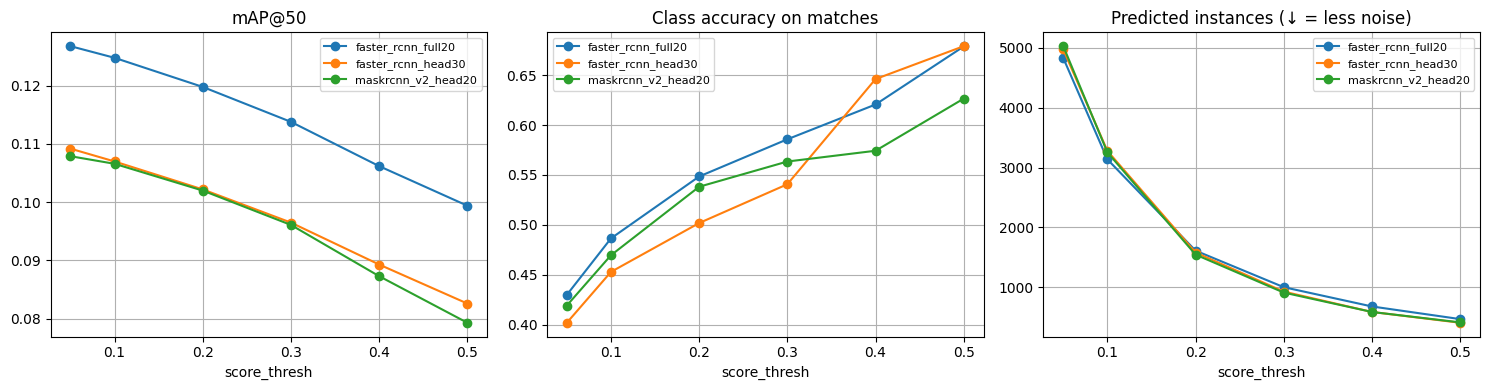

In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [
    ("bbox_map_50",          "mAP@50"),
    ("class_acc_on_matches", "Class accuracy on matches"),
    ("pred_instances",       "Predicted instances (↓ = less noise)"),
]

for ax, (col, title) in zip(axes, metrics):
    for name, grp in sweep_df.groupby("checkpoint"):
        ax.plot(grp["score_thresh"], grp[col], marker="o", label=name)
    ax.set_xlabel("score_thresh")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
print("\nBest threshold per checkpoint (by mAP@50):")
print(sweep_df.loc[sweep_df.groupby("checkpoint")["bbox_map_50"].idxmax()])

### Observations

**0.05** produces the highest `mAP@0.5` for every checkpoint. Increasing the threshold improves conditional classification accuracy and removes noisy predictions, but reduces recall, match rate, and mAP. Threshold tuning therefore changes the precision-recall trade-off but does not solve the underlying model problem.

## Bucket 2 (class taxonomy, 2-epoch test)

This bucket tests whether confusion can be reduced by:

- Merging `Plastic bag & wrapper` and `Other plastic` into `Flexible plastic`.
- Removing annotations that would otherwise belong to `Other`.
- Training the revised taxonomy for two epochs.

The revised model is compared with the original `top-10` baseline at equivalent early epochs.

In [24]:
PLASTIC_MERGE = {"Plastic bag & wrapper", "Other plastic"}
MERGED_NAME   = "Flexible plastic"

In [16]:
def make_merged_taxonomy_df(
    df: pd.DataFrame,
) -> tuple[pd.DataFrame, dict[str, int], int, dict[int, str]]:
    """Merge overlapping plastic classes and remove catch-all annotations.

    Args:
        df (pd.DataFrame): Annotation dataframe containing a
            ``supercategory`` column.

    Returns:
        tuple[pd.DataFrame, dict[str, int], int, dict[int, str]]: Filtered
            annotations, label-to-ID mapping, total class count including
            background, and reverse ID-to-name mapping.
    """
    # Define the explicit taxonomy from the most frequent source categories.
    top_supercats = set(df["supercategory"].value_counts().head(10).index)

    # Replace visually overlapping plastic classes before filtering annotations.
    df_new = df.copy()
    df_new["label_merged"] = df_new["supercategory"].replace(
        {c: MERGED_NAME for c in PLASTIC_MERGE}
    )

    # Drop annotations outside the explicit taxonomy instead of creating Other.
    keep = (top_supercats - PLASTIC_MERGE) | {MERGED_NAME}
    df_new = df_new[df_new["label_merged"].isin(keep)].copy()

    # Detection class IDs start at 1 because 0 is reserved for background.
    label_values = sorted(df_new["label_merged"].unique())
    label_map    = {name: i + 1 for i, name in enumerate(label_values)}
    num_classes  = len(label_map) + 1
    id_to_name   = {v: k for k, v in label_map.items()}

    print(f"Classes ({len(label_map)}): {label_values}")
    print(f"Annotations: {len(df_new)} (was {len(df)})")
    return df_new, label_map, num_classes, id_to_name

### Setup

In [21]:
df_merged, label_map_merged, num_classes_merged, id_to_name_merged = make_merged_taxonomy_df(df)

train_loader_merged, val_loader_merged = get_loaders(
    df=df_merged,
    label_map=label_map_merged,
    label_col="label_merged",
    train_transform=None,
    return_masks=True,
    use_original_boxes=True,
    train_batch_size=5,
    val_batch_size=5,
    num_workers=6,
)

Classes (9): ['Bottle', 'Bottle cap', 'Can', 'Carton', 'Cigarette', 'Cup', 'Flexible plastic', 'Straw', 'Unlabeled litter']
Annotations: 3912 (was 4784)


### Train 2 epochs

In [31]:
run_prefix_merged = "hyp10_merged_plastic_heads_2"

model_merged = get_model(num_classes=num_classes_merged, train_mode="heads")

optimizer_merged = torch.optim.SGD(
    [p for p in model_merged.parameters() if p.requires_grad],
    lr=1e-3, momentum=0.9, weight_decay=0.0005,
)
scheduler_merged = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_merged, mode="max", factor=0.5, patience=2, min_lr=1e-5,
)
scaler_merged = torch.amp.GradScaler("cuda")
writer_merged = SummaryWriter(log_dir=os.path.join(DEFAULT_RUNS_PATH, f"runs/{run_prefix_merged}"))

history_merged = train_model(
    model=model_merged,
    train_loader=train_loader_merged,
    val_loader=val_loader_merged,
    optimizer=optimizer_merged,
    scheduler=scheduler_merged,
    scaler=scaler_merged,
    writer=writer_merged,
    num_epoch=2,
    run_prefix=run_prefix_merged,
    device=device,
    eval_every=1,
    metrics_csv_paths={
        "train": os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix_merged}_train.csv"),
        "eval":  os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix_merged}_eval.csv"),
    },
    checkpoint_score_fn=score_by_eval_bbox_map_50,
    scheduler_step_fn=step_on_val_bbox_map_50,
    id_to_name=id_to_name_merged,
    fast=True
)

Train model. Epoch 2: 100%|██████████| 2/2 [17:38<00:00, 529.30s/it]


###  Compare against baseline

In [32]:
baseline_df = pd.read_csv(os.path.join(DEFAULT_RUNS_PATH, "hyp4_top10_heads_5_eval.csv"))
merged_df   = pd.read_csv(os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix_merged}_eval.csv"))

COLS = ["epoch", "eval/bbox_map_50", "eval/class_accuracy_on_matches",
        "eval/match_rate", "eval/pred_instances"]

comparison = pd.concat([
    baseline_df[COLS].assign(run="baseline_top10"),
    merged_df[COLS].assign(run="merged_plastic"),
]).sort_values(["run", "epoch"])

print(comparison.to_string(index=False))

 epoch  eval/bbox_map_50  eval/class_accuracy_on_matches  eval/match_rate  eval/pred_instances            run
     0          0.072403                        0.313869         0.344221               4851.0 baseline_top10
     1          0.097972                        0.340067         0.373116               4561.0 baseline_top10
     2          0.105328                        0.378049         0.412060               5440.0 baseline_top10
     3          0.117431                        0.363057         0.394472               4383.0 baseline_top10
     4          0.118244                        0.374613         0.405779               4394.0 baseline_top10
     0          0.038638                        0.372807         0.297650               4221.0 merged_plastic
     1          0.067325                        0.346491         0.297650               4238.0 merged_plastic


### Observations

The merged model performs worse during both evaluated epochs. At epoch 1, its `mAP@0.5` is approximately **0.067**, compared with 0.098 for the baseline. Its match rate also remains lower, while classification accuracy shows no consistent improvement.

The result does not support this taxonomy change in its current form. However, removing Other also removes **872** annotations, so this experiment changes both the taxonomy and the training dataset.

## Bucket 3 -  Augmentation verification — 5-epoch trajectory comparison

This bucket tests whether additional image variation improves generalization. The taxonomy, split, model, and optimizer remain aligned with the baseline, while the training set receives flips, scale changes, rotations, brightness and contrast changes, and blur.

A five-epoch trajectory is compared with the non-augmented baseline. The purpose is to determine whether augmentation improves mAP immediately or produces a curve that continues improving after the baseline plateaus.

In [19]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    A.RandomScale(scale_limit=0.3, p=0.5),
    A.Rotate(limit=15, p=0.3),
    A.GaussianBlur(blur_limit=(3, 7), p=0.2),
])

In [22]:
df_aug, label_map_aug, num_classes_aug, id_to_name_aug = make_reduced_supercategory_df(
    df=df, top_k=10, classless=False,
)

In [23]:
train_loader_aug, val_loader_aug = get_loaders_original_boxes(
    df=df_aug,
    label_map=label_map_aug,
    label_col="label_reduced",
    train_transform=train_transform,   # ← only difference from baseline
    return_masks=True,
    use_original_boxes=True,
    batch_size_train=5,
    batch_size_val=5,
    num_workers=6,
    use_weighted_sampler=True,
)

In [39]:
run_prefix_aug = "hyp10_augmentation_heads_5"

model_aug = get_model(num_classes=num_classes_aug, train_mode="heads")

optimizer_aug = torch.optim.SGD(
    [p for p in model_aug.parameters() if p.requires_grad],
    lr=1e-3, momentum=0.9, weight_decay=0.0005,
)
scheduler_aug = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_aug, mode="max", factor=0.5, patience=2, min_lr=1e-5,
)
scaler_aug  = torch.amp.GradScaler("cuda")
writer_aug  = SummaryWriter(log_dir=os.path.join(DEFAULT_RUNS_PATH, f"runs/{run_prefix_aug}"))

history_aug = train_model(
    model=model_aug,
    train_loader=train_loader_aug,
    val_loader=val_loader_aug,
    optimizer=optimizer_aug,
    scheduler=scheduler_aug,
    scaler=scaler_aug,
    writer=writer_aug,
    num_epoch=5,
    run_prefix=run_prefix_aug,
    device=device,
    eval_every=1,
    metrics_csv_paths={
        "train": os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix_aug}_train.csv"),
        "eval":  os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix_aug}_eval.csv"),
    },
    checkpoint_score_fn=score_by_eval_bbox_map_50,
    scheduler_step_fn=step_on_val_bbox_map_50,
    id_to_name=id_to_name_aug,
    fast=True,
)

Train model. Epoch 5: 100%|██████████| 5/5 [53:44<00:00, 644.91s/it]


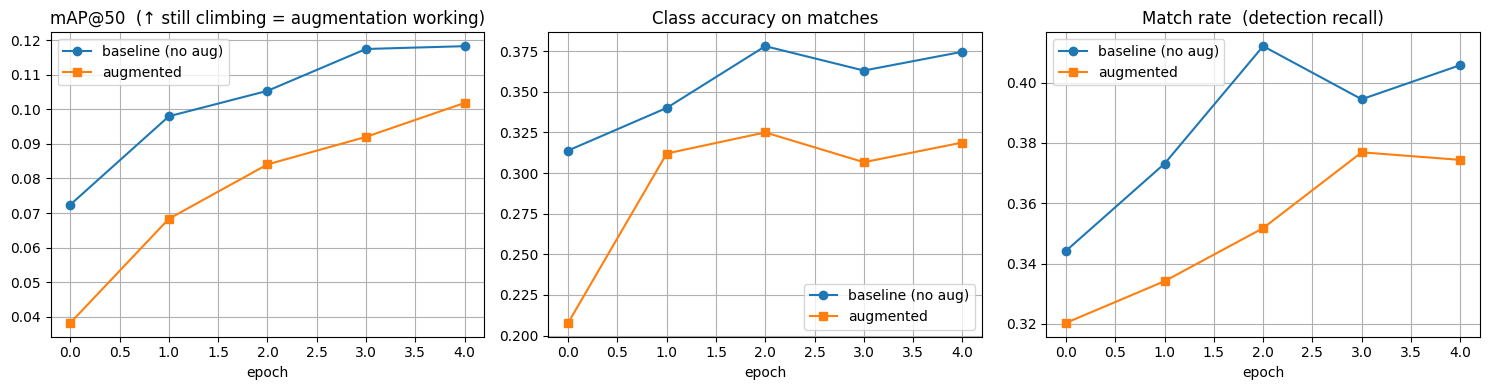

In [40]:
baseline_df = pd.read_csv(os.path.join(DEFAULT_RUNS_PATH, "hyp4_top10_heads_5_eval.csv"))
aug_df      = pd.read_csv(os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix_aug}_eval.csv"))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = [
    ("eval/bbox_map_50",               "mAP@50  (↑ still climbing = augmentation working)"),
    ("eval/class_accuracy_on_matches", "Class accuracy on matches"),
    ("eval/match_rate",                "Match rate  (detection recall)"),
]

for ax, (col, title) in zip(axes, metrics):
    ax.plot(baseline_df["epoch"], baseline_df[col], marker="o", label="baseline (no aug)")
    ax.plot(aug_df["epoch"],      aug_df[col],      marker="s", label="augmented")
    ax.set_xlabel("epoch")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [41]:
!rclone copy ./taco_trash gdrive:taco_trash --progress
!rclone copy checkpoints gdrive:taco_trash/checkpoints --progress

Transferred:   	    4.052 KiB / 4.052 KiB, 100%, 0 B/s, ETA -
Checks:                 0 / 1, 0%, Listed 78
Transferred:            0 / 4, 0%
Elapsed time:         0.5s
Checking:
 *                   hyp4_top10_heads_5_eval.csv: checking
Transferring:
 *           hyp10_augmentation_heads_5_eval.csv:100% / 1.941 KiB, 0 B/s, -
 *          hyp10_augmentation_heads_5_train.csv:100% / 724 B, 0 B/s, -
 *         hyp10_merged_plastic_heads_2_eval.csv:100% / 1.051 KiB, 0 B/s, -
 *        hyp10_merged_plastic_heads_2_train.csv:100% / 361 B, 0 B/s, -Transferred:   	    4.052 KiB / 4.052 KiB, 100%, 0 B/s, ETA -
Checks:                 1 / 1, 100%, Listed 80
Transferred:            0 / 4, 0%
Elapsed time:         1.0s
Transferring:
 *           hyp10_augmentation_heads_5_eval.csv:100% / 1.941 KiB, 0 B/s, -
 *          hyp10_augmentation_heads_5_train.csv:100% / 724 B, 0 B/s, -
 *         hyp10_merged_plastic_heads_2_eval.csv:100% / 1.051 KiB, 0 B/s, -
 *        hyp10_merged_plastic_heads_2_train.c

In [25]:
# Merged taxonomy + augmentation together
df_final, label_map_final, num_classes_final, id_to_name_final = make_merged_taxonomy_df(df)

train_loader_final, val_loader_final = get_loaders_original_boxes(
    df=df_final,
    label_map=label_map_final,
    label_col="label_merged",
    train_transform=train_transform,   # augmentation
    return_masks=True,
    use_original_boxes=True,
    batch_size_train=5,
    batch_size_val=5,
    num_workers=6,
    use_weighted_sampler=True,
)

Classes (9): ['Bottle', 'Bottle cap', 'Can', 'Carton', 'Cigarette', 'Cup', 'Flexible plastic', 'Straw', 'Unlabeled litter']
Annotations: 3912 (was 4784)


In [26]:
def step_cosine(
    scheduler: torch.optim.lr_scheduler.LRScheduler,
    train_metrics: dict[str, Any],
    val_metrics: dict[str, Any] | None,
) -> None:
    """Advance a non-metric-based scheduler after one training epoch.

    Args:
        scheduler (torch.optim.lr_scheduler.LRScheduler): Scheduler to advance.
        train_metrics (dict[str, Any]): Training metrics accepted for callback
            compatibility but not used by cosine annealing.
        val_metrics (dict[str, Any] | None): Optional validation metrics, also
            unused by cosine annealing.
    """
    # CosineAnnealingLR depends on epoch count rather than a monitored metric.
    scheduler.step()

In [ ]:
num_epochs=20
run_prefix_final = f"hyp10_combined_aug_merged_cosine_{num_epochs}"

model_final = get_model(num_classes=num_classes_final, train_mode="heads")
_ = load_checkpoint(
  path=os.path.join(ROOT_PATH, "checkpoints",  "hyp10_combined_aug_merged_cosine_20_best_model.pt"),
  model=model_final,
  device=device,
)

optimizer_final = torch.optim.SGD(
    [p for p in model_final.parameters() if p.requires_grad],
    lr=1e-3, momentum=0.9, weight_decay=0.0005,
)
scheduler_final = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_final, T_max=20, eta_min=1e-6,
)
scaler_final  = torch.amp.GradScaler("cuda")
writer_final  = SummaryWriter(log_dir=os.path.join(DEFAULT_RUNS_PATH, f"runs/{run_prefix_final}"))

history_aug = train_model(
    model=model_final,
    train_loader=train_loader_final,
    val_loader=val_loader_final,
    optimizer=optimizer_final,
    scheduler=scheduler_final,
    scaler=scaler_final,
    writer=writer_final,
    num_epoch=num_epochs,
    run_prefix=run_prefix_final,
    device=device,
    eval_every=1,
    metrics_csv_paths={
        "train": os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix_final}_train.csv"),
        "eval":  os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix_final}_eval.csv"),
    },
    checkpoint_score_fn=score_by_eval_bbox_map_50,
    scheduler_step_fn=step_cosine,
    id_to_name=id_to_name_final,
    start_epoch=8,
    fast=True,
)

Epoch 20. Eval:   5%|▌         | 3/55 [00:23<06:24,  7.38s/it]

In [ ]:
if not is_google_colab():
    !rclone copy ./taco_trash gdrive:taco_trash --progress
    !rclone copy checkpoints gdrive:taco_trash/checkpoints --progress

### Observations

The augmented model improves throughout the five epochs but remains below the baseline:

- Final `mAP@0.5`: approximately **0.101** versus **0.118**.
- Final match rate: approximately **0.374** versus **0.406**.
- Final classification accuracy: approximately **0.319** versus **0.375**.

The upward trajectory suggests that longer training could help, but the current experiment provides no evidence that these augmentations outperform the baseline.

## Conclusion

The completed buckets do not show a clear improvement over the original configuration:

- Raising the score threshold reduces mAP despite improving conditional accuracy.
- Merging plastic classes and dropping Other decreases early detection performance.
- Augmentation learns more slowly and remains below the baseline after five epochs.

The combined experiment cannot yet validate the complete hypothesis because its output is incomplete. More importantly, the current code creates model_final with train_mode="heads", so the backbone is still frozen. Therefore, the “unfreeze backbone” part has not actually been tested. Use `train_mode="all"` for that experiment.

Because the final run changes taxonomy, dataset size, augmentation, scheduler, and training mode simultaneously, any improvement would be difficult to attribute to one cause. The strongest experimental design is to test full fine-tuning separately before combining it with the other changes.

# Overall Conclusion

The experiments show that the main limitation is not insufficient training time or the choice of confidence threshold. Detection quality is primarily constrained by dataset complexity, object scale, and ambiguous class definitions.

The classless model achieved the strongest result, with bbox `mAP@0.5` ≈ **0.213**, while `top-5` and `top-10` models reached approximately **0.134** and **0.128**. Localization match rate changed much less than classification accuracy. This demonstrates that the model can often locate an object but struggles to assign the correct category.

Object size is another major limitation. Approximately _67%_ of objects are tiny or small. Match rate increases from **0.271** for tiny objects to **0.760** for large objects, showing that small-object localization strongly reduces recall and mAP.

Other findings were less significant:

- Weighted sampling did not explain the classification problem.
- Original bounding boxes performed slightly better than mask-derived boxes.
- The Other class causes some confusion but is not the only problematic class.
- Merging plastic classes and removing Other did not improve short-run performance.
- Raising the score threshold improved accuracy among retained predictions but reduced `recall` and `mAP`.
- The tested augmentations learned more slowly and remained below the baseline after five epochs.
- Longer training and full fine-tuning produced limited gains after validation performance plateaued.

Overall, the experiments suggest that further improvement requires a better label taxonomy and stronger handling of small objects rather than simply adding epochs. The most promising directions are semantically coherent class grouping, class-specific data inspection, higher-resolution or tiled training, scale-aware augmentation, and carefully controlled full-backbone fine-tuning.

The experiments also establish a useful upper bound: the substantially stronger classless result confirms that the model has meaningful localization capability. The remaining gap is largely caused by fine-grained classification and dataset structure.